# Entrenamiento y evaluación de modelos para predecir la variable **default** 

In [168]:
from pathlib import Path

import pandas as pd

DATA_DIR = Path().resolve().parent.parent / "data/data-09-2025"
data_file = "cleaned_data_default.parquet"

df = pd.read_parquet(DATA_DIR / data_file)
df.head()

,plazo,vinculacion,v_cuota,v_prestamo,s_capital,s_intereses,aportes,garantias,valorgarantia,ctasahorros,...,actividadeconomica,estado_cliente,departamento,sexo,curtotalingresos,curtotalegresos,intestrato,actualizacion,default,puntaje_data
n_credito,,,,,,,,,,,,,,,,,,,,,
003-002-0125852-7,1827,8103,356849.0,15000000.0,12923538.0,123855,7741255,1,7741255,33042953.0,...,asalariados,1,antioquia,0,4597000.0,1500000.0,5.0,1,0,795.0
004-002-0068475-5,1826,1434,2650409.0,100460000.0,31911361.0,263265,4601706,1,4601706,3791115.0,...,asalariados,1,antioquia,0,4597000.0,650000.0,5.0,1,0,836.0
003-002-0122592-9,1826,573,791482.0,30000000.0,23844684.0,261477,530431,1,530431,94435.0,...,asalariados,1,antioquia,0,4400000.0,2000000.0,4.0,0,1,709.0
006-002-0023879-0,2922,1902,2860501.0,176000000.0,113842595.0,1008570,3023534,2,320385440,54841.0,...,educacion_basica_secundaria,1,antioquia,0,22020000.0,1500000.0,4.0,1,0,733.0
006-002-0026159-4,2557,1902,987637.0,50300000.0,38521256.0,317167,1023082,2,320385440,54841.0,...,educacion_basica_secundaria,1,antioquia,0,22020000.0,1500000.0,4.0,1,0,695.0


In [169]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12860 entries, 003-002-0125852-7 to 003-002-0119478-4
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   plazo               12860 non-null  int64   
 1   vinculacion         12860 non-null  int64   
 2   v_cuota             12860 non-null  float64 
 3   v_prestamo          12860 non-null  float64 
 4   s_capital           12860 non-null  float64 
 5   s_intereses         12860 non-null  int64   
 6   aportes             12860 non-null  int64   
 7   garantias           12860 non-null  int64   
 8   valorgarantia       12860 non-null  int64   
 9   ctasahorros         12860 non-null  float64 
 10  edad                12860 non-null  float64 
 11  tipoasociado        12860 non-null  int64   
 12  actividadeconomica  12851 non-null  category
 13  estado_cliente      12860 non-null  int64   
 14  departamento        12859 non-null  category
 15  sexo         

In [ ]:
# Codificación binaria de estado_cliente y garantias

from sklearn.preprocessing import OneHotEncoder

oe_binarias = OneHotEncoder(drop="if_binary", dtype=int, max_categories=2)

var_binarias = ["estado_cliente", "departamento", "actividadeconomica"]

for var in var_binarias:
    encoded = oe_binarias.fit_transform(df[[var]])
    encoded_df = pd.DataFrame(
        encoded.toarray(),
        columns=oe_binarias.get_feature_names_out([var]),
        index=df.index,
    )
    df = df.drop(columns=[var])
    df = pd.concat([df, encoded_df], axis=1)

In [171]:
df.head()

,plazo,vinculacion,v_cuota,v_prestamo,s_capital,s_intereses,aportes,garantias,valorgarantia,ctasahorros,...,sexo,curtotalingresos,curtotalegresos,intestrato,actualizacion,default,puntaje_data,estado_cliente_infrequent_sklearn,departamento_infrequent_sklearn,actividadeconomica_infrequent_sklearn
n_credito,,,,,,,,,,,,,,,,,,,,,
003-002-0125852-7,1827,8103,356849.0,15000000.0,12923538.0,123855,7741255,1,7741255,33042953.0,...,0,4597000.0,1500000.0,5.0,1,0,795.0,0,0,0
004-002-0068475-5,1826,1434,2650409.0,100460000.0,31911361.0,263265,4601706,1,4601706,3791115.0,...,0,4597000.0,650000.0,5.0,1,0,836.0,0,0,0
003-002-0122592-9,1826,573,791482.0,30000000.0,23844684.0,261477,530431,1,530431,94435.0,...,0,4400000.0,2000000.0,4.0,0,1,709.0,0,0,0
006-002-0023879-0,2922,1902,2860501.0,176000000.0,113842595.0,1008570,3023534,2,320385440,54841.0,...,0,22020000.0,1500000.0,4.0,1,0,733.0,0,0,1
006-002-0026159-4,2557,1902,987637.0,50300000.0,38521256.0,317167,1023082,2,320385440,54841.0,...,0,22020000.0,1500000.0,4.0,1,0,695.0,0,0,1


In [173]:
oe_encoder_garantias = OneHotEncoder(drop="if_binary", dtype=int, max_categories=3)

garantias_encoded = oe_encoder_garantias.fit_transform(df[["garantias"]])

garantias_encoded_df = pd.DataFrame(
    garantias_encoded.toarray(),
    columns=oe_encoder_garantias.get_feature_names_out(["garantias"]),
    index=df.index,
)

df = df.drop(columns=["garantias"])
df = pd.concat([df, garantias_encoded_df], axis=1)

df.rename(
    columns={
        "estado_cliente_infrequent_sklearn": "estado_cliente_no_1",
        "departamento_infrequent_sklearn": "departamento_no_antioquia",
        "actividadeconomica_infrequent_sklearn": "actividadeconomica_no_asalariado",
        "garantias_infrequent_sklearn": "garantias_no_1_no_9",
    },
    inplace=True,
)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12860 entries, 003-002-0125852-7 to 003-002-0119478-4
Data columns (total 24 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   plazo                             12860 non-null  int64  
 1   vinculacion                       12860 non-null  int64  
 2   v_cuota                           12860 non-null  float64
 3   v_prestamo                        12860 non-null  float64
 4   s_capital                         12860 non-null  float64
 5   s_intereses                       12860 non-null  int64  
 6   aportes                           12860 non-null  int64  
 7   valorgarantia                     12860 non-null  int64  
 8   ctasahorros                       12860 non-null  float64
 9   edad                              12860 non-null  float64
 10  tipoasociado                      12860 non-null  int64  
 11  sexo                              12860 non-

In [175]:
from sklearn.model_selection import train_test_split

X = df.drop("default", axis=1)
y = df["default"]

# We separate the data into training and testing.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=1
)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

Training set size: (10288, 23)
Testing set size: (2572, 23)


## Pruebas rápidas con modelos sin sintonizar

In [176]:
from sklearn.metrics import f1_score
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=1, max_depth=5)
model.fit(X_train, y_train)
train_score = f1_score(y_train, model.predict(X_train))
test_score = f1_score(y_test, model.predict(X_test))
print(f"Train score: {train_score:.2f}")
print(f"Test score: {test_score:.2f}")

Train score: 0.71
Test score: 0.64


In [177]:
feature_importances = pd.Series(model.feature_importances_, index=X_train.columns)
feature_importances.sort_values(ascending=False, inplace=True)
feature_importances

actualizacion                       0.275066
valorgarantia                       0.268037
s_intereses                         0.176237
ctasahorros                         0.074099
v_prestamo                          0.070700
vinculacion                         0.066913
curtotalingresos                    0.060516
edad                                0.003262
tipoasociado                        0.002400
s_capital                           0.001503
intestrato                          0.001267
aportes                             0.000000
v_cuota                             0.000000
plazo                               0.000000
sexo                                0.000000
curtotalegresos                     0.000000
puntaje_data                        0.000000
estado_cliente_no_1                 0.000000
departamento_no_antioquia           0.000000
actividadeconomica_no_asalariado    0.000000
garantias_1                         0.000000
garantias_9                         0.000000
garantias_

In [178]:
from xgboost import XGBClassifier

model = XGBClassifier(
    grow_policy="lossguide",
    tree_method="hist",
    enable_categorical=True,
    early_stopping_rounds=20,
    eval_metric="auc",
    random_state=1,
)

model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

train_score = f1_score(y_train, model.predict(X_train), average="macro")
test_score = f1_score(y_test, model.predict(X_test), average="macro")
print(f"Train score: {train_score:.2f}")
print(f"Test score: {test_score:.2f}")

Train score: 1.00
Test score: 0.86


In [179]:
feature_importances = pd.Series(model.feature_importances_, index=X_train.columns)
feature_importances.sort_values(ascending=False, inplace=True)
feature_importances

actualizacion                       0.415622
tipoasociado                        0.076748
valorgarantia                       0.062081
ctasahorros                         0.055233
s_intereses                         0.050479
v_cuota                             0.034494
vinculacion                         0.032516
garantias_9                         0.031181
curtotalingresos                    0.029272
v_prestamo                          0.028905
garantias_1                         0.027258
puntaje_data                        0.026550
plazo                               0.021900
aportes                             0.020284
s_capital                           0.018680
actividadeconomica_no_asalariado    0.014710
sexo                                0.013297
edad                                0.011981
curtotalegresos                     0.011334
intestrato                          0.009105
estado_cliente_no_1                 0.008370
departamento_no_antioquia           0.000000
garantias_

In [180]:
from sklearn.metrics import classification_report

print(classification_report(y_test, model.predict(X_test)))

              precision    recall  f1-score   support

           0       0.94      0.97      0.95      2126
           1       0.84      0.69      0.76       446

    accuracy                           0.92      2572
   macro avg       0.89      0.83      0.86      2572
weighted avg       0.92      0.92      0.92      2572



In [181]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, model.predict(X_test))
print(cm)

[[2069   57]
 [ 140  306]]


In [184]:
import lightgbm as lgb
from lightgbm import LGBMClassifier

model = LGBMClassifier(
    objective="binary",  # Objetivo de clasificación binaria
    class_weight="balanced",  # Hace balanceo de clases
    verbose=0,
    random_state=1,
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],  # Conjunto de validación
    eval_metric="logloss",  # 'auc', 'error', etc.
    callbacks=[lgb.early_stopping(stopping_rounds=20)],
)

train_score = f1_score(y_train, model.predict(X_train))
test_score = f1_score(y_test, model.predict(X_test))
print(f"Train score: {train_score:.2f}")
print(f"Test score: {test_score:.2f}")

Training until validation scores don't improve for 20 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's binary_logloss: 0.20461
Train score: 0.91
Test score: 0.77


In [ ]:
feature_importances = pd.Series(model.feature_importances_, index=X_train.columns)
feature_importances.sort_values(ascending=False, inplace=True)
feature_importances

s_intereses                         447
vinculacion                         356
valorgarantia                       245
puntaje_data                        233
curtotalingresos                    225
v_cuota                             221
s_capital                           208
ctasahorros                         199
plazo                               173
v_prestamo                          164
aportes                             132
edad                                119
tipoasociado                         81
curtotalegresos                      66
actualizacion                        56
intestrato                           24
sexo                                 24
garantias_9                          10
actividadeconomica_no_asalariado      9
garantias_1                           4
estado_cliente_no_1                   4
departamento_no_antioquia             0
garantias_no_1_no_9                   0
dtype: int32

In [186]:
print(classification_report(y_test, model.predict(X_test)))

              precision    recall  f1-score   support

           0       0.96      0.94      0.95      2126
           1       0.73      0.82      0.77       446

    accuracy                           0.92      2572
   macro avg       0.85      0.88      0.86      2572
weighted avg       0.92      0.92      0.92      2572



In [188]:
print(confusion_matrix(y_test, model.predict(X_test)))

[[1990  136]
 [  80  366]]


## Sintonización de modelos

### LightGBM

In [212]:
import optuna


def objective(trial):
    param = {
        "lambda_l1": trial.suggest_float("lambda_l1", 1e-8, 10.0, log=True),
        "lambda_l2": trial.suggest_float("lambda_l2", 1e-8, 10.0, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 50, 500),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.4, 1.0),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.4, 1.0),
        "bagging_freq": trial.suggest_int("bagging_freq", 1, 7),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1, 10),
    }

    categorical_features = X_train.select_dtypes(include=["category"]).columns.tolist()

    model = LGBMClassifier(
        **param,
        objective="binary",
        force_col_wise=True,
        random_state=1,
    )

    model.fit(
        X_train,
        y_train,
        categorical_feature=categorical_features,
        eval_set=[(X_test, y_test)],
        callbacks=[lgb.early_stopping(stopping_rounds=20)],
    )

    preds = model.predict(X_test)
    f1 = f1_score(y_test, preds.round())

    return f1


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)
print(
    f"Best trial: {study.best_trial.value:.3f} with params: {study.best_trial.params}"
)  # noqa: E501

[I 2026-02-25 19:38:52,951] A new study created in memory with name: no-name-6eec3d94-db53-4249-bf9f-18b34efb8ff6


[LightGBM] [Warning] feature_fraction is set=0.7867977570920017, colsample_bytree=0.7282298493619503 will be ignored. Current value: feature_fraction=0.7867977570920017
[LightGBM] [Warning] lambda_l1 is set=0.0007646759845324643, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.0007646759845324643
[LightGBM] [Warning] lambda_l2 is set=5.016660154101763e-07, reg_lambda=0.0 will be ignored. Current value: lambda_l2=5.016660154101763e-07
[LightGBM] [Warning] bagging_fraction is set=0.9653225239142718, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9653225239142718
[LightGBM] [Warning] bagging_freq is set=6, subsample_freq=0 will be ignored. Current value: bagging_freq=6
[LightGBM] [Warning] feature_fraction is set=0.7867977570920017, colsample_bytree=0.7282298493619503 will be ignored. Current value: feature_fraction=0.7867977570920017
[LightGBM] [Warning] lambda_l1 is set=0.0007646759845324643, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.000764675

[I 2026-02-25 19:38:53,393] Trial 0 finished with value: 0.727447216890595 and parameters: {'lambda_l1': 0.0007646759845324643, 'lambda_l2': 5.016660154101763e-07, 'num_leaves': 458, 'feature_fraction': 0.7867977570920017, 'bagging_fraction': 0.9653225239142718, 'bagging_freq': 6, 'min_child_samples': 97, 'learning_rate': 0.017418908819943752, 'colsample_bytree': 0.7282298493619503, 'scale_pos_weight': 7.2428523429757155}. Best is trial 0 with value: 0.727447216890595.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Did not meet early stopping. Best iteration is:
[100]	valid_0's binary_logloss: 0.286468
[LightGBM] [Warning] feature_fraction is set=0.7867977570920017, colsample_bytree=0.7282298493619503 will be ignored. Current value: feature_fraction=0.7867977570920017
[LightGBM] [Warning] lambda_l1 is set=0.0007646759845324643, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.0007646759845324643
[LightGBM] [Warning] lambda_l2 is set=5.016660154101763e-07, reg_lambda=0.0 will be ignored. Current value: lambda_l2=5.016660154101763e-07
[LightGBM] [Warning] bagging_fraction is set=0.9653225239142718, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9653225239142718
[LightGBM] [Warning] bagging_freq is set=6, subsample_freq=0 will be ignored. Current value: bagging_freq=6
[LightGBM] [Warning] feature_fraction is set=0.65852239118

[I 2026-02-25 19:38:53,893] Trial 1 finished with value: 0.7721518987341772 and parameters: {'lambda_l1': 9.087731565898516e-05, 'lambda_l2': 1.0865105505620438e-05, 'num_leaves': 343, 'feature_fraction': 0.6585223911897975, 'bagging_fraction': 0.7379908029084012, 'bagging_freq': 3, 'min_child_samples': 55, 'learning_rate': 0.053275533419217834, 'colsample_bytree': 0.96630059169635, 'scale_pos_weight': 5.678708786731268}. Best is trial 1 with value: 0.7721518987341772.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-02-25 19:38:54,121] Trial 2 finished with value: 0.7408866995073892 and parameters: {'lambda_l1': 3.0830143499508964e-06, 'lambda_l2': 0.09956129344507675, 'num_leaves': 81, 'feature_fraction': 0.6916291286213726, 'bagging_fraction': 0.4323649922137099, 'bagging_freq': 6, 'min_child_samples': 48, 'learning_rate': 0.021484238083813566, 'colsample_bytree': 0.7184498522664465, 'scale_pos_weight': 7.562133235289769}. Best is trial 1 with value: 0.7721518987341772.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-02-25 19:38:54,713] Trial 3 finished with value: 0.7890535917901939 and parameters: {'lambda_l1': 0.00015327618565368973, 'lambda_l2': 4.789721297790004e-05, 'num_leaves': 323, 'feature_fraction': 0.6735241420128624, 'bagging_fraction': 0.6196713838930441, 'bagging_freq': 1, 'min_child_samples': 18, 'learning_rate': 0.07985184110741972, 'colsample_bytree': 0.7303796657595175, 'scale_pos_weight': 6.557385405400451}. Best is trial 3 with value: 0.7890535917901939.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Early stopping, best iteration is:
[68]	valid_0's binary_logloss: 0.180865
[LightGBM] [Warning] feature_fraction is set=0.6735241420128624, colsample_bytree=0.7303796657595175 will be ignored. Current value: feature_fraction=0.6735241420128624
[LightGBM] [Warning] lambda_l1 is set=0.00015327618565368973, reg_alpha=0.0 will 

[I 2026-02-25 19:38:55,113] Trial 4 finished with value: 0.76751269035533 and parameters: {'lambda_l1': 2.1564009653849032e-05, 'lambda_l2': 1.7120133936769386, 'num_leaves': 336, 'feature_fraction': 0.7154161379302948, 'bagging_fraction': 0.40789494884656896, 'bagging_freq': 1, 'min_child_samples': 67, 'learning_rate': 0.11052573158553995, 'colsample_bytree': 0.6752656350930275, 'scale_pos_weight': 7.997185926361585}. Best is trial 3 with value: 0.7890535917901939.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Did not meet early stopping. Best iteration is:
[100]	valid_0's binary_logloss: 0.230295
[LightGBM] [Warning] feature_fraction is set=0.7154161379302948, colsample_bytree=0.6752656350930275 will be ignored. Current value: feature_fraction=0.7154161379302948
[LightGBM] [Warning] lambda_l1 is set=2.1564009653849032e-05, reg_alpha=0.0 will be ignored. Current value: lambda_l1=2.1564009653849032e-05
[LightGBM] [Warning] lambda_l2 is set=1.7120133936769386, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.7120133936769386
[LightGBM] [Warning] bagging_fraction is set=0.40789494884656896, subsample=1.0 will be ignored. Current value: bagging_fraction=0.40789494884656896
[LightGBM] [Warnin

[I 2026-02-25 19:38:55,675] Trial 5 finished with value: 0.7729918509895227 and parameters: {'lambda_l1': 3.975178508415108e-06, 'lambda_l2': 0.0004724185973672538, 'num_leaves': 137, 'feature_fraction': 0.5907680447289594, 'bagging_fraction': 0.5827369870234542, 'bagging_freq': 7, 'min_child_samples': 46, 'learning_rate': 0.09508477791059797, 'colsample_bytree': 0.9319339679120326, 'scale_pos_weight': 2.2396421863045193}. Best is trial 3 with value: 0.7890535917901939.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-02-25 19:38:56,036] Trial 6 finished with value: 0.7138863000931966 and parameters: {'lambda_l1': 1.4760244692113154e-05, 'lambda_l2': 7.080158235657595, 'num_leaves': 495, 'feature_fraction': 0.8278975971107503, 'bagging_fraction': 0.6791121759945506, 'bagging_freq': 6, 'min_child_samples': 25, 'learning_rate': 0.02055320655596734, 'colsample_bytree': 0.5685737725350668, 'scale_pos_weight': 9.238813575811161}. Best is trial 3 with value: 0.7890535917901939.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-02-25 19:38:56,437] Trial 7 finished with value: 0.743801652892562 and parameters: {'lambda_l1': 1.527530983207812e-05, 'lambda_l2': 3.308688403493437e-08, 'num_leaves': 436, 'feature_fraction': 0.869125650780993, 'bagging_fraction': 0.457193196939889, 'bagging_freq': 6, 'min_child_samples': 41, 'learning_rate': 0.021279473452680244, 'colsample_bytree': 0.5888783488716695, 'scale_pos_weight': 4.982991642736518}. Best is trial 3 with value: 0.7890535917901939.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-02-25 19:38:57,548] Trial 8 finished with value: 0.7734553775743707 and parameters: {'lambda_l1': 2.9175579145883546e-08, 'lambda_l2': 1.6513494011475152e-05, 'num_leaves': 425, 'feature_fraction': 0.614805764922238, 'bagging_fraction': 0.8549030823844741, 'bagging_freq': 7, 'min_child_samples': 14, 'learning_rate': 0.01902825861080778, 'colsample_bytree': 0.9925069926455312, 'scale_pos_weight': 7.7732440973562875}. Best is trial 3 with value: 0.7890535917901939.


Did not meet early stopping. Best iteration is:
[100]	valid_0's binary_logloss: 0.218634
[LightGBM] [Warning] feature_fraction is set=0.614805764922238, colsample_bytree=0.9925069926455312 will be ignored. Current value: feature_fraction=0.614805764922238
[LightGBM] [Warning] lambda_l1 is set=2.9175579145883546e-08, reg_alpha=0.0 will be ignored. Current value: lambda_l1=2.9175579145883546e-08
[LightGBM] [Warning] lambda_l2 is set=1.6513494011475152e-05, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.6513494011475152e-05
[LightGBM] [Warning] bagging_fraction is set=0.8549030823844741, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8549030823844741
[LightGBM] [Warning] bagging_freq is set=7, subsample_freq=0 will be ignored. Current value: bagging_freq=7
[LightGBM] [Warning] feature_fraction is set=0.9773807950523785, colsample_bytree=0.7181723844340318 will be ignored. Current value: feature_fraction=0.9773807950523785
[LightGBM] [Warning] lambda_l1 is set

[I 2026-02-25 19:38:57,983] Trial 9 finished with value: 0.7674661105318039 and parameters: {'lambda_l1': 6.183785291622604e-08, 'lambda_l2': 7.622885829470929e-05, 'num_leaves': 101, 'feature_fraction': 0.9773807950523785, 'bagging_fraction': 0.9684963560790635, 'bagging_freq': 6, 'min_child_samples': 98, 'learning_rate': 0.07482682958032325, 'colsample_bytree': 0.7181723844340318, 'scale_pos_weight': 6.661172268489466}. Best is trial 3 with value: 0.7890535917901939.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-02-25 19:38:58,305] Trial 10 finished with value: 0.7647058823529411 and parameters: {'lambda_l1': 0.7916215366618294, 'lambda_l2': 0.0036589029898901515, 'num_leaves': 212, 'feature_fraction': 0.4322340285601767, 'bagging_fraction': 0.5937886324093707, 'bagging_freq': 1, 'min_child_samples': 17, 'learning_rate': 0.20100390952833846, 'colsample_bytree': 0.8462170050995286, 'scale_pos_weight': 3.6485453775360384}. Best is trial 3 with value: 0.7890535917901939.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Early stopping, best iteration is:
[43]	valid_0's binary_logloss: 0.19595
[LightGBM] [Warning] feature_fraction is set=0.4322340285601767, colsample_bytree=0.8462170050995286 will be ignored. Current value: feature_fraction=0.4322340285601767
[LightGBM] [Warning] lambda_l1 is set=0.7916215366618294, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.7916215366618294
[LightGBM] [Warning] lambda_l2 is set=0.0036589029898901515, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.0036589029898901515
[LightGBM] [Warning] bagging_fraction is set=0.5937886324093707, subsample=1.0 will be ignored. Current value: bagging_fraction=0.5937886324093707
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] feature_fraction is set=0.5286365767913075, colsample_bytr

[I 2026-02-25 19:38:59,992] Trial 11 finished with value: 0.7750294464075382 and parameters: {'lambda_l1': 1.951581479733522e-08, 'lambda_l2': 2.86350667824214e-06, 'num_leaves': 365, 'feature_fraction': 0.5286365767913075, 'bagging_fraction': 0.8398103234653289, 'bagging_freq': 3, 'min_child_samples': 9, 'learning_rate': 0.04046389539867599, 'colsample_bytree': 0.8399964183270716, 'scale_pos_weight': 9.60926978580974}. Best is trial 3 with value: 0.7890535917901939.


Did not meet early stopping. Best iteration is:
[100]	valid_0's binary_logloss: 0.184251
[LightGBM] [Warning] feature_fraction is set=0.5286365767913075, colsample_bytree=0.8399964183270716 will be ignored. Current value: feature_fraction=0.5286365767913075
[LightGBM] [Warning] lambda_l1 is set=1.951581479733522e-08, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1.951581479733522e-08
[LightGBM] [Warning] lambda_l2 is set=2.86350667824214e-06, reg_lambda=0.0 will be ignored. Current value: lambda_l2=2.86350667824214e-06
[LightGBM] [Warning] bagging_fraction is set=0.8398103234653289, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8398103234653289
[LightGBM] [Warning] bagging_freq is set=3, subsample_freq=0 will be ignored. Current value: bagging_freq=3
[LightGBM] [Warning] feature_fraction is set=0.4946467764796052, colsample_bytree=0.8254537225373156 will be ignored. Current value: feature_fraction=0.4946467764796052
[LightGBM] [Warning] lambda_l1 is set=0.0

[I 2026-02-25 19:39:01,619] Trial 12 finished with value: 0.7762237762237763 and parameters: {'lambda_l1': 0.013485676700423872, 'lambda_l2': 8.555961270296194e-07, 'num_leaves': 291, 'feature_fraction': 0.4946467764796052, 'bagging_fraction': 0.8087830909344521, 'bagging_freq': 3, 'min_child_samples': 8, 'learning_rate': 0.03942068382169591, 'colsample_bytree': 0.8254537225373156, 'scale_pos_weight': 9.000510381842172}. Best is trial 3 with value: 0.7890535917901939.


[LightGBM] [Warning] feature_fraction is set=0.4946467764796052, colsample_bytree=0.8254537225373156 will be ignored. Current value: feature_fraction=0.4946467764796052
[LightGBM] [Warning] lambda_l1 is set=0.013485676700423872, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.013485676700423872
[LightGBM] [Warning] lambda_l2 is set=8.555961270296194e-07, reg_lambda=0.0 will be ignored. Current value: lambda_l2=8.555961270296194e-07
[LightGBM] [Warning] bagging_fraction is set=0.8087830909344521, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8087830909344521
[LightGBM] [Warning] bagging_freq is set=3, subsample_freq=0 will be ignored. Current value: bagging_freq=3
[LightGBM] [Warning] feature_fraction is set=0.4057863489464093, colsample_bytree=0.8279233075834308 will be ignored. Current value: feature_fraction=0.4057863489464093
[LightGBM] [Warning] lambda_l1 is set=0.03637860395393928, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.0363786039539

[I 2026-02-25 19:39:02,717] Trial 13 finished with value: 0.7684426229508197 and parameters: {'lambda_l1': 0.03637860395393928, 'lambda_l2': 2.6223601254785518e-08, 'num_leaves': 257, 'feature_fraction': 0.4057863489464093, 'bagging_fraction': 0.7583010136910905, 'bagging_freq': 2, 'min_child_samples': 29, 'learning_rate': 0.03486031964330545, 'colsample_bytree': 0.8279233075834308, 'scale_pos_weight': 9.933183791254674}. Best is trial 3 with value: 0.7890535917901939.


[LightGBM] [Warning] feature_fraction is set=0.4057863489464093, colsample_bytree=0.8279233075834308 will be ignored. Current value: feature_fraction=0.4057863489464093
[LightGBM] [Warning] lambda_l1 is set=0.03637860395393928, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.03637860395393928
[LightGBM] [Warning] lambda_l2 is set=2.6223601254785518e-08, reg_lambda=0.0 will be ignored. Current value: lambda_l2=2.6223601254785518e-08
[LightGBM] [Warning] bagging_fraction is set=0.7583010136910905, subsample=1.0 will be ignored. Current value: bagging_fraction=0.7583010136910905
[LightGBM] [Warning] bagging_freq is set=2, subsample_freq=0 will be ignored. Current value: bagging_freq=2
[LightGBM] [Warning] feature_fraction is set=0.5022451476435057, colsample_bytree=0.635771003967538 will be ignored. Current value: feature_fraction=0.5022451476435057
[LightGBM] [Warning] lambda_l1 is set=0.0060498348389336695, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.006049834838

[I 2026-02-25 19:39:04,146] Trial 14 finished with value: 0.6960110041265475 and parameters: {'lambda_l1': 0.0060498348389336695, 'lambda_l2': 3.952185672787235e-07, 'num_leaves': 203, 'feature_fraction': 0.5022451476435057, 'bagging_fraction': 0.5923682933824906, 'bagging_freq': 4, 'min_child_samples': 7, 'learning_rate': 0.010465214015211876, 'colsample_bytree': 0.635771003967538, 'scale_pos_weight': 5.213416442860668}. Best is trial 3 with value: 0.7890535917901939.


Did not meet early stopping. Best iteration is:
[100]	valid_0's binary_logloss: 0.266744
[LightGBM] [Warning] feature_fraction is set=0.5022451476435057, colsample_bytree=0.635771003967538 will be ignored. Current value: feature_fraction=0.5022451476435057
[LightGBM] [Warning] lambda_l1 is set=0.0060498348389336695, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.0060498348389336695
[LightGBM] [Warning] lambda_l2 is set=3.952185672787235e-07, reg_lambda=0.0 will be ignored. Current value: lambda_l2=3.952185672787235e-07
[LightGBM] [Warning] bagging_fraction is set=0.5923682933824906, subsample=1.0 will be ignored. Current value: bagging_fraction=0.5923682933824906
[LightGBM] [Warning] bagging_freq is set=4, subsample_freq=0 will be ignored. Current value: bagging_freq=4
[LightGBM] [Warning] feature_fraction is set=0.5170555327216165, colsample_bytree=0.7952630773443203 will be ignored. Current value: feature_fraction=0.5170555327216165
[LightGBM] [Warning] lambda_l1 is set=9.

[I 2026-02-25 19:39:04,673] Trial 15 finished with value: 0.7679671457905544 and parameters: {'lambda_l1': 9.268035650444153, 'lambda_l2': 0.000905065336086153, 'num_leaves': 295, 'feature_fraction': 0.5170555327216165, 'bagging_fraction': 0.829175337179924, 'bagging_freq': 2, 'min_child_samples': 31, 'learning_rate': 0.15331171616506925, 'colsample_bytree': 0.7952630773443203, 'scale_pos_weight': 8.819804076175256}. Best is trial 3 with value: 0.7890535917901939.


[LightGBM] [Warning] feature_fraction is set=0.7714487020061856, colsample_bytree=0.898472957437043 will be ignored. Current value: feature_fraction=0.7714487020061856
[LightGBM] [Warning] lambda_l1 is set=0.043023762160062214, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.043023762160062214
[LightGBM] [Warning] lambda_l2 is set=0.007683017088431499, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.007683017088431499
[LightGBM] [Warning] bagging_fraction is set=0.6488365655242525, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6488365655242525
[LightGBM] [Warning] bagging_freq is set=4, subsample_freq=0 will be ignored. Current value: bagging_freq=4
[LightGBM] [Warning] feature_fraction is set=0.7714487020061856, colsample_bytree=0.898472957437043 will be ignored. Current value: feature_fraction=0.7714487020061856
[LightGBM] [Warning] lambda_l1 is set=0.043023762160062214, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.0430237621600622

[I 2026-02-25 19:39:05,321] Trial 16 finished with value: 0.7758081334723671 and parameters: {'lambda_l1': 0.043023762160062214, 'lambda_l2': 0.007683017088431499, 'num_leaves': 261, 'feature_fraction': 0.7714487020061856, 'bagging_fraction': 0.6488365655242525, 'bagging_freq': 4, 'min_child_samples': 72, 'learning_rate': 0.06292730865356813, 'colsample_bytree': 0.898472957437043, 'scale_pos_weight': 6.137049773716356}. Best is trial 3 with value: 0.7890535917901939.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-02-25 19:39:06,019] Trial 17 finished with value: 0.7402452619843924 and parameters: {'lambda_l1': 0.002228561233498215, 'lambda_l2': 1.3402341484097555e-06, 'num_leaves': 383, 'feature_fraction': 0.5853734284901417, 'bagging_fraction': 0.5101068980582364, 'bagging_freq': 2, 'min_child_samples': 21, 'learning_rate': 0.28547638827464245, 'colsample_bytree': 0.7780648609473024, 'scale_pos_weight': 4.1774727800072995}. Best is trial 3 with value: 0.7890535917901939.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Early stopping, best iteration is:
[22]	valid_0's binary_logloss: 0.226828
[LightGBM] [Warning] feature_fraction is set=0.5853734284901417, colsample_bytree=0.7780648609473024 will be ignored. Current value: feature_fraction=0.5853734284901417
[LightGBM] [Warning] lambda_l1 is set=0.002228561233498215, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.002228561233498215
[LightGBM] [Warning

[I 2026-02-25 19:39:06,739] Trial 18 finished with value: 0.7617866004962779 and parameters: {'lambda_l1': 0.0236209433293858, 'lambda_l2': 4.370593034733751e-05, 'num_leaves': 198, 'feature_fraction': 0.4799782890413657, 'bagging_fraction': 0.7470281075004821, 'bagging_freq': 3, 'min_child_samples': 36, 'learning_rate': 0.03353600652908251, 'colsample_bytree': 0.5213914040081117, 'scale_pos_weight': 1.4649706282743145}. Best is trial 3 with value: 0.7890535917901939.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-02-25 19:39:08,587] Trial 19 finished with value: 0.7631578947368421 and parameters: {'lambda_l1': 4.525048393008067e-07, 'lambda_l2': 1.169017428561587e-07, 'num_leaves': 294, 'feature_fraction': 0.912154511129039, 'bagging_fraction': 0.515013498713261, 'bagging_freq': 1, 'min_child_samples': 5, 'learning_rate': 0.04573259228451407, 'colsample_bytree': 0.8860949623985992, 'scale_pos_weight': 8.483827529394715}. Best is trial 3 with value: 0.7890535917901939.


Early stopping, best iteration is:
[77]	valid_0's binary_logloss: 0.191868
[LightGBM] [Warning] feature_fraction is set=0.912154511129039, colsample_bytree=0.8860949623985992 will be ignored. Current value: feature_fraction=0.912154511129039
[LightGBM] [Warning] lambda_l1 is set=4.525048393008067e-07, reg_alpha=0.0 will be ignored. Current value: lambda_l1=4.525048393008067e-07
[LightGBM] [Warning] lambda_l2 is set=1.169017428561587e-07, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.169017428561587e-07
[LightGBM] [Warning] bagging_fraction is set=0.515013498713261, subsample=1.0 will be ignored. Current value: bagging_fraction=0.515013498713261
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] feature_fraction is set=0.7309422443320676, colsample_bytree=0.6620451222321078 will be ignored. Current value: feature_fraction=0.7309422443320676
[LightGBM] [Warning] lambda_l1 is set=0.00019606310182582

[I 2026-02-25 19:39:09,444] Trial 20 finished with value: 0.7739801543550165 and parameters: {'lambda_l1': 0.00019606310182582496, 'lambda_l2': 0.047418899744382875, 'num_leaves': 392, 'feature_fraction': 0.7309422443320676, 'bagging_fraction': 0.9029908453391228, 'bagging_freq': 5, 'min_child_samples': 64, 'learning_rate': 0.12388023426147599, 'colsample_bytree': 0.6620451222321078, 'scale_pos_weight': 6.7421043727545635}. Best is trial 3 with value: 0.7890535917901939.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Early stopping, best iteration is:
[76]	valid_0's binary_logloss: 0.199652
[LightGBM] [Warning] feature_fraction is set=0.7309422443320676, colsample_bytree=0.6620451222321078 will be ignored. Current value: feature_fraction=0.7309422443320676
[LightGBM] [Warning] lambda_l1 is set=0.00019606310182582496, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.00019606310182582496
[LightGBM] [Warning] lambda_l2 is set=0.047418899744382875, reg_lambda=0.0 will be ignored

[I 2026-02-25 19:39:10,076] Trial 21 finished with value: 0.768595041322314 and parameters: {'lambda_l1': 0.4368330195253781, 'lambda_l2': 0.007733250483262393, 'num_leaves': 277, 'feature_fraction': 0.7750428620355793, 'bagging_fraction': 0.6576428563508202, 'bagging_freq': 4, 'min_child_samples': 81, 'learning_rate': 0.0718578911123711, 'colsample_bytree': 0.921043038343026, 'scale_pos_weight': 6.067631160606554}. Best is trial 3 with value: 0.7890535917901939.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Did not meet early stopping. Best iteration is:
[100]	valid_0's binary_logloss: 0.212366
[LightGBM] [Warning] feature_fraction is set=0.7750428620355793, colsample_bytree=0.921043038343026 will be ignored. Current value: feature_fraction=0.7750428620355793
[LightGBM] [Warning] lambda_l1 is set=0.4368330195253781, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.4368330195253781
[LightGBM]

[I 2026-02-25 19:39:10,812] Trial 22 finished with value: 0.7734204793028322 and parameters: {'lambda_l1': 0.10632116845872712, 'lambda_l2': 0.00014277878036052778, 'num_leaves': 248, 'feature_fraction': 0.6358959527982052, 'bagging_fraction': 0.6497223988624292, 'bagging_freq': 5, 'min_child_samples': 81, 'learning_rate': 0.0753976840026134, 'colsample_bytree': 0.8804338971523752, 'scale_pos_weight': 4.043923607903372}. Best is trial 3 with value: 0.7890535917901939.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-02-25 19:39:11,877] Trial 23 finished with value: 0.7543323139653415 and parameters: {'lambda_l1': 0.0037300447696443123, 'lambda_l2': 4.671560239464507e-06, 'num_leaves': 320, 'feature_fraction': 0.7743850281909663, 'bagging_fraction': 0.6276355001226629, 'bagging_freq': 3, 'min_child_samples': 76, 'learning_rate': 0.060407983369351, 'colsample_bytree': 0.7737206129399652, 'scale_pos_weight': 6.394581555244018}. Best is trial 3 with value: 0.7890535917901939.


[LightGBM] [Warning] feature_fraction is set=0.5480662094745344, colsample_bytree=0.8927808301383224 will be ignored. Current value: feature_fraction=0.5480662094745344
[LightGBM] [Warning] lambda_l1 is set=0.0004535796261229864, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.0004535796261229864
[LightGBM] [Warning] lambda_l2 is set=0.014213854074030528, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.014213854074030528
[LightGBM] [Warning] bagging_fraction is set=0.7810453076459857, subsample=1.0 will be ignored. Current value: bagging_fraction=0.7810453076459857
[LightGBM] [Warning] bagging_freq is set=4, subsample_freq=0 will be ignored. Current value: bagging_freq=4
[LightGBM] [Warning] feature_fraction is set=0.5480662094745344, colsample_bytree=0.8927808301383224 will be ignored. Current value: feature_fraction=0.5480662094745344
[LightGBM] [Warning] lambda_l1 is set=0.0004535796261229864, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.00045357962

[I 2026-02-25 19:39:12,516] Trial 24 finished with value: 0.7722980062959076 and parameters: {'lambda_l1': 0.0004535796261229864, 'lambda_l2': 0.014213854074030528, 'num_leaves': 158, 'feature_fraction': 0.5480662094745344, 'bagging_fraction': 0.7810453076459857, 'bagging_freq': 4, 'min_child_samples': 59, 'learning_rate': 0.03125101537358555, 'colsample_bytree': 0.8927808301383224, 'scale_pos_weight': 4.577173801687803}. Best is trial 3 with value: 0.7890535917901939.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-02-25 19:39:13,078] Trial 25 finished with value: 0.7690721649484537 and parameters: {'lambda_l1': 1.5156400640406391, 'lambda_l2': 0.0012084345445872017, 'num_leaves': 236, 'feature_fraction': 0.6695037866670138, 'bagging_fraction': 0.7025030796539432, 'bagging_freq': 5, 'min_child_samples': 71, 'learning_rate': 0.08921360164595077, 'colsample_bytree': 0.8138957257082172, 'scale_pos_weight': 8.439458312671515}. Best is trial 3 with value: 0.7890535917901939.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-02-25 19:39:13,562] Trial 26 finished with value: 0.7682403433476395 and parameters: {'lambda_l1': 0.019119373313221014, 'lambda_l2': 0.4408876089412281, 'num_leaves': 310, 'feature_fraction': 0.8857483351359527, 'bagging_fraction': 0.5555273817052762, 'bagging_freq': 2, 'min_child_samples': 87, 'learning_rate': 0.05489071717000917, 'colsample_bytree': 0.7477545704830073, 'scale_pos_weight': 3.3807872258949536}. Best is trial 3 with value: 0.7890535917901939.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-02-25 19:39:14,517] Trial 27 finished with value: 0.7741228070175439 and parameters: {'lambda_l1': 0.19970724589085978, 'lambda_l2': 2.645758766190378e-05, 'num_leaves': 152, 'feature_fraction': 0.7344025555067036, 'bagging_fraction': 0.6990693274631365, 'bagging_freq': 3, 'min_child_samples': 15, 'learning_rate': 0.02796021831797354, 'colsample_bytree': 0.8612094557014466, 'scale_pos_weight': 6.97907895814336}. Best is trial 3 with value: 0.7890535917901939.


Did not meet early stopping. Best iteration is:
[100]	valid_0's binary_logloss: 0.202821
[LightGBM] [Warning] feature_fraction is set=0.7344025555067036, colsample_bytree=0.8612094557014466 will be ignored. Current value: feature_fraction=0.7344025555067036
[LightGBM] [Warning] lambda_l1 is set=0.19970724589085978, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.19970724589085978
[LightGBM] [Warning] lambda_l2 is set=2.645758766190378e-05, reg_lambda=0.0 will be ignored. Current value: lambda_l2=2.645758766190378e-05
[LightGBM] [Warning] bagging_fraction is set=0.6990693274631365, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6990693274631365
[LightGBM] [Warning] bagging_freq is set=3, subsample_freq=0 will be ignored. Current value: bagging_freq=3
[LightGBM] [Warning] feature_fraction is set=0.4547100524761683, colsample_bytree=0.9338209294913594 will be ignored. Current value: feature_fraction=0.4547100524761683
[LightGBM] [Warning] lambda_l1 is set=0.001

[I 2026-02-25 19:39:15,345] Trial 28 finished with value: 0.7801104972375691 and parameters: {'lambda_l1': 0.0012685295387537372, 'lambda_l2': 0.00018139351770448759, 'num_leaves': 362, 'feature_fraction': 0.4547100524761683, 'bagging_fraction': 0.7895823628217375, 'bagging_freq': 4, 'min_child_samples': 36, 'learning_rate': 0.15000508528375534, 'colsample_bytree': 0.9338209294913594, 'scale_pos_weight': 9.099803554180978}. Best is trial 3 with value: 0.7890535917901939.


[LightGBM] [Warning] feature_fraction is set=0.4547100524761683, colsample_bytree=0.9338209294913594 will be ignored. Current value: feature_fraction=0.4547100524761683
[LightGBM] [Warning] lambda_l1 is set=0.0012685295387537372, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.0012685295387537372
[LightGBM] [Warning] lambda_l2 is set=0.00018139351770448759, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.00018139351770448759
[LightGBM] [Warning] bagging_fraction is set=0.7895823628217375, subsample=1.0 will be ignored. Current value: bagging_fraction=0.7895823628217375
[LightGBM] [Warning] bagging_freq is set=4, subsample_freq=0 will be ignored. Current value: bagging_freq=4
[LightGBM] [Warning] feature_fraction is set=0.4468620651073937, colsample_bytree=0.9410140939974085 will be ignored. Current value: feature_fraction=0.4468620651073937
[LightGBM] [Warning] lambda_l1 is set=0.0009787862911583177, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.0009787

[I 2026-02-25 19:39:16,082] Trial 29 finished with value: 0.7786606129398411 and parameters: {'lambda_l1': 0.0009787862911583177, 'lambda_l2': 2.617615970785234e-07, 'num_leaves': 405, 'feature_fraction': 0.4468620651073937, 'bagging_fraction': 0.8936456910178079, 'bagging_freq': 1, 'min_child_samples': 35, 'learning_rate': 0.1661792573327355, 'colsample_bytree': 0.9410140939974085, 'scale_pos_weight': 9.361199700122976}. Best is trial 3 with value: 0.7890535917901939.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Early stopping, best iteration is:
[59]	valid_0's binary_logloss: 0.192451
[LightGBM] [Warning] feature_fraction is set=0.4468620651073937, colsample_bytree=0.9410140939974085 will be ignored. Current value: feature_fraction=0.4468620651073937
[LightGBM] [Warning] lambda_l1 is set=0.0009787862911583177, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.0009787862911583177
[LightGBM] [Warning] lambda_l2 is set=2.617615970785234e-07, reg_lambda=0.0 will be ignored. Current value: lambda_l2=2.617615970785234e-07
[LightGBM] [Warning] baggin

[I 2026-02-25 19:39:16,722] Trial 30 finished with value: 0.781354051054384 and parameters: {'lambda_l1': 0.0012077390812656203, 'lambda_l2': 1.4379619082936564e-07, 'num_leaves': 484, 'feature_fraction': 0.45262689602967704, 'bagging_fraction': 0.9228508426269456, 'bagging_freq': 1, 'min_child_samples': 36, 'learning_rate': 0.19473050299089975, 'colsample_bytree': 0.9532718817601261, 'scale_pos_weight': 9.539604987866495}. Best is trial 3 with value: 0.7890535917901939.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Early stopping, best iteration is:
[42]	valid_0's binary_logloss: 0.197948
[LightGBM] [Warning] feature_fraction is set=0.45262689602967704, colsample_bytree=0.9532718817601261 will be ignored. Current value: feature_fraction=0.45262689602967704
[Lig

[I 2026-02-25 19:39:17,338] Trial 31 finished with value: 0.7697441601779755 and parameters: {'lambda_l1': 0.0011125219850183945, 'lambda_l2': 2.740184731731342e-07, 'num_leaves': 484, 'feature_fraction': 0.46162361215843906, 'bagging_fraction': 0.9017622547059037, 'bagging_freq': 1, 'min_child_samples': 36, 'learning_rate': 0.18317678854400807, 'colsample_bytree': 0.9565830580602918, 'scale_pos_weight': 9.462255156446991}. Best is trial 3 with value: 0.7890535917901939.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Early stopping, best iteration is:
[43]	valid_0's binary_logloss: 0.20288
[LightGBM] [Warning] feature_fraction is set=0.46162361215843906, colsample_bytree=0.9565830580602918 will be ignored. Current value: feature_fraction=0.46162361215843906
[LightGBM] [Warning] lambda_l1 is set=0.0011125219850183945, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.0011125219850183945
[LightGBM] [Warn

[I 2026-02-25 19:39:17,913] Trial 32 finished with value: 0.7666290868094702 and parameters: {'lambda_l1': 8.834241279998124e-05, 'lambda_l2': 1.7543415644122526e-08, 'num_leaves': 454, 'feature_fraction': 0.40483778542051563, 'bagging_fraction': 0.9180045402625123, 'bagging_freq': 1, 'min_child_samples': 40, 'learning_rate': 0.2672167999372276, 'colsample_bytree': 0.9961201311086952, 'scale_pos_weight': 8.47571561739491}. Best is trial 3 with value: 0.7890535917901939.


[LightGBM] [Warning] feature_fraction is set=0.40483778542051563, colsample_bytree=0.9961201311086952 will be ignored. Current value: feature_fraction=0.40483778542051563
[LightGBM] [Warning] lambda_l1 is set=8.834241279998124e-05, reg_alpha=0.0 will be ignored. Current value: lambda_l1=8.834241279998124e-05
[LightGBM] [Warning] lambda_l2 is set=1.7543415644122526e-08, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.7543415644122526e-08
[LightGBM] [Warning] bagging_fraction is set=0.9180045402625123, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9180045402625123
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] feature_fraction is set=0.5575523736212633, colsample_bytree=0.9468285823171158 will be ignored. Current value: feature_fraction=0.5575523736212633
[LightGBM] [Warning] lambda_l1 is set=0.00018358881957858747, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.0001

[I 2026-02-25 19:39:18,626] Trial 33 finished with value: 0.7775330396475771 and parameters: {'lambda_l1': 0.00018358881957858747, 'lambda_l2': 8.851961858812812e-08, 'num_leaves': 404, 'feature_fraction': 0.5575523736212633, 'bagging_fraction': 0.9931275255597902, 'bagging_freq': 2, 'min_child_samples': 51, 'learning_rate': 0.14800636027152714, 'colsample_bytree': 0.9468285823171158, 'scale_pos_weight': 7.578584833069481}. Best is trial 3 with value: 0.7890535917901939.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Early stopping, best iteration is:
[56]	valid_0's binary_logloss: 0.195235
[LightGBM] [Warning] feature_fraction is set=0.5575523736212633, colsample_bytree=0.9468285823171158 will be ignored. Current value: feature_fraction=0.5575523736212633
[LightGBM] [Warning] lambda_l1 is set=0.00018358881957858747, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.00018358881957858747
[LightGBM] [Warning] lambda_l2 is set=8.851961858812812e-08, reg_lambda=0.0 will be ignored. Current value: lambda_l2=8.851961858812812e-08
[LightGBM] [Warning] bagging_fraction is set=0.9931275255597902, subsample=1.0 will be ignored. Curr

[I 2026-02-25 19:39:19,272] Trial 34 finished with value: 0.7739032620922385 and parameters: {'lambda_l1': 0.0009708100124473473, 'lambda_l2': 4.976766246612424e-06, 'num_leaves': 352, 'feature_fraction': 0.4503225358866262, 'bagging_fraction': 0.8663319124266348, 'bagging_freq': 1, 'min_child_samples': 29, 'learning_rate': 0.20984273040325485, 'colsample_bytree': 0.9734901334733176, 'scale_pos_weight': 9.937145991973265}. Best is trial 3 with value: 0.7890535917901939.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Early stopping, best iteration is:
[43]	valid_0's binary_logloss: 0.197321
[LightGBM] [Warning] feature_fraction is set=0.4503225358866262, colsample_bytree=0.9734901334733176 will be ignored. Current value: feature_fraction=0.4503225358866262
[LightGBM] [Warning] lambda_l1 is set=0.0009708100124473473, reg_alpha=0.0 will b

[I 2026-02-25 19:39:20,341] Trial 35 finished with value: 0.786114221724524 and parameters: {'lambda_l1': 4.7080797931313224e-05, 'lambda_l2': 0.00011358771999093903, 'num_leaves': 465, 'feature_fraction': 0.4338603712518279, 'bagging_fraction': 0.9329287158233875, 'bagging_freq': 1, 'min_child_samples': 45, 'learning_rate': 0.1294744615777614, 'colsample_bytree': 0.9181603821971959, 'scale_pos_weight': 8.013623535634526}. Best is trial 3 with value: 0.7890535917901939.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Early stopping, best iteration is:
[75]	valid_0's binary_logloss: 0.186967
[LightGBM] [Warning] feature_fraction is set=0.4338603712518279, colsample_bytree=0.9181603821971959 will be ignored. Current value: feature_fraction=0.4338603712518279
[LightGBM] [Warning] lambda_l1 is set=4.7080797931313224e-05, reg_alpha=0.0 will be ignored. Current value: lambda_l1=4.7080797931313224e-05
[LightGBM] [War

[I 2026-02-25 19:39:21,360] Trial 36 finished with value: 0.7856341189674523 and parameters: {'lambda_l1': 6.499684380277376e-05, 'lambda_l2': 0.0001352392285326274, 'num_leaves': 480, 'feature_fraction': 0.5768803800384968, 'bagging_fraction': 0.9324638953115518, 'bagging_freq': 2, 'min_child_samples': 44, 'learning_rate': 0.11912778513114641, 'colsample_bytree': 0.9174076683260945, 'scale_pos_weight': 8.208303350141266}. Best is trial 3 with value: 0.7890535917901939.


[LightGBM] [Warning] feature_fraction is set=0.5768803800384968, colsample_bytree=0.9174076683260945 will be ignored. Current value: feature_fraction=0.5768803800384968
[LightGBM] [Warning] lambda_l1 is set=6.499684380277376e-05, reg_alpha=0.0 will be ignored. Current value: lambda_l1=6.499684380277376e-05
[LightGBM] [Warning] lambda_l2 is set=0.0001352392285326274, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.0001352392285326274
[LightGBM] [Warning] bagging_fraction is set=0.9324638953115518, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9324638953115518
[LightGBM] [Warning] bagging_freq is set=2, subsample_freq=0 will be ignored. Current value: bagging_freq=2
[LightGBM] [Warning] feature_fraction is set=0.6705855987305491, colsample_bytree=0.6839816636473163 will be ignored. Current value: feature_fraction=0.6705855987305491
[LightGBM] [Warning] lambda_l1 is set=2.8284696492234172e-06, reg_alpha=0.0 will be ignored. Current value: lambda_l1=2.82846964

[I 2026-02-25 19:39:22,250] Trial 37 finished with value: 0.7797356828193832 and parameters: {'lambda_l1': 2.8284696492234172e-06, 'lambda_l2': 0.00037479226439889437, 'num_leaves': 463, 'feature_fraction': 0.6705855987305491, 'bagging_fraction': 0.9443956772738626, 'bagging_freq': 2, 'min_child_samples': 45, 'learning_rate': 0.11993627447502198, 'colsample_bytree': 0.6839816636473163, 'scale_pos_weight': 7.322322847926495}. Best is trial 3 with value: 0.7890535917901939.


[LightGBM] [Warning] feature_fraction is set=0.6705855987305491, colsample_bytree=0.6839816636473163 will be ignored. Current value: feature_fraction=0.6705855987305491
[LightGBM] [Warning] lambda_l1 is set=2.8284696492234172e-06, reg_alpha=0.0 will be ignored. Current value: lambda_l1=2.8284696492234172e-06
[LightGBM] [Warning] lambda_l2 is set=0.00037479226439889437, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.00037479226439889437
[LightGBM] [Warning] bagging_fraction is set=0.9443956772738626, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9443956772738626
[LightGBM] [Warning] bagging_freq is set=2, subsample_freq=0 will be ignored. Current value: bagging_freq=2
[LightGBM] [Warning] feature_fraction is set=0.585055464522307, colsample_bytree=0.7061227515674868 will be ignored. Current value: feature_fraction=0.585055464522307
[LightGBM] [Warning] lambda_l1 is set=5.5104757277035295e-05, reg_alpha=0.0 will be ignored. Current value: lambda_l1=5.510475

[I 2026-02-25 19:39:23,102] Trial 38 finished with value: 0.7780269058295964 and parameters: {'lambda_l1': 5.5104757277035295e-05, 'lambda_l2': 1.1817374557233295e-05, 'num_leaves': 469, 'feature_fraction': 0.585055464522307, 'bagging_fraction': 0.9466335446362517, 'bagging_freq': 1, 'min_child_samples': 53, 'learning_rate': 0.1000226835266987, 'colsample_bytree': 0.7061227515674868, 'scale_pos_weight': 5.659560744988288}. Best is trial 3 with value: 0.7890535917901939.


[LightGBM] [Warning] feature_fraction is set=0.585055464522307, colsample_bytree=0.7061227515674868 will be ignored. Current value: feature_fraction=0.585055464522307
[LightGBM] [Warning] lambda_l1 is set=5.5104757277035295e-05, reg_alpha=0.0 will be ignored. Current value: lambda_l1=5.5104757277035295e-05
[LightGBM] [Warning] lambda_l2 is set=1.1817374557233295e-05, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.1817374557233295e-05
[LightGBM] [Warning] bagging_fraction is set=0.9466335446362517, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9466335446362517
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] feature_fraction is set=0.6229510199505732, colsample_bytree=0.7423057002931506 will be ignored. Current value: feature_fraction=0.6229510199505732
[LightGBM] [Warning] lambda_l1 is set=4.890014434249145e-06, reg_alpha=0.0 will be ignored. Current value: lambda_l1=4.8900144

[I 2026-02-25 19:39:24,107] Trial 39 finished with value: 0.7759197324414716 and parameters: {'lambda_l1': 4.890014434249145e-06, 'lambda_l2': 0.0015081930623324716, 'num_leaves': 496, 'feature_fraction': 0.6229510199505732, 'bagging_fraction': 0.8724249819760997, 'bagging_freq': 2, 'min_child_samples': 23, 'learning_rate': 0.23791800278450476, 'colsample_bytree': 0.7423057002931506, 'scale_pos_weight': 8.03865839996761}. Best is trial 3 with value: 0.7890535917901939.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Early stopping, best iteration is:
[25]	valid_0's binary_logloss: 0.194811
[LightGBM] [Warning] feature_fraction is set=0.6229510199505732, colsample_bytree=0.7423057002931506 will be ignored. Current value: feature_fraction=0.6229510199505732
[LightGBM] [Warning] lambda_l1 is set=4.890014434249145e-06, reg_alpha=0.0 will be ignored. Current value: lambda_l1=4.890014434249145e-06
[LightGBM] [Warning] lambda_l2 is set=0.0015081930623324716, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.0015081930623324716
[LightGBM] [Warning] bagging_fraction is set=0.8724249819760997, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8724249819760997
[LightGBM] [Warning] bagging_freq is set=2, subsample_freq=0 will be ignored. Current value: bagging_freq=2
[LightGBM] [Warning] feature_fraction is set=0.7031657663728451, colsample_bytree=0.9144584048624407 will be ignored. Current value: feature_fracti

[I 2026-02-25 19:39:24,962] Trial 40 finished with value: 0.7787610619469026 and parameters: {'lambda_l1': 4.193375932986815e-05, 'lambda_l2': 9.027421242649391e-05, 'num_leaves': 434, 'feature_fraction': 0.7031657663728451, 'bagging_fraction': 0.9994350350579826, 'bagging_freq': 1, 'min_child_samples': 58, 'learning_rate': 0.1291311780726783, 'colsample_bytree': 0.9144584048624407, 'scale_pos_weight': 8.140846560172593}. Best is trial 3 with value: 0.7890535917901939.


[LightGBM] [Warning] feature_fraction is set=0.7031657663728451, colsample_bytree=0.9144584048624407 will be ignored. Current value: feature_fraction=0.7031657663728451
[LightGBM] [Warning] lambda_l1 is set=4.193375932986815e-05, reg_alpha=0.0 will be ignored. Current value: lambda_l1=4.193375932986815e-05
[LightGBM] [Warning] lambda_l2 is set=9.027421242649391e-05, reg_lambda=0.0 will be ignored. Current value: lambda_l2=9.027421242649391e-05
[LightGBM] [Warning] bagging_fraction is set=0.9994350350579826, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9994350350579826
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] feature_fraction is set=0.47669140868388077, colsample_bytree=0.9703517697848123 will be ignored. Current value: feature_fraction=0.47669140868388077
[LightGBM] [Warning] lambda_l1 is set=0.0002945696971403484, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.0002945

[I 2026-02-25 19:39:25,757] Trial 41 finished with value: 0.7786259541984732 and parameters: {'lambda_l1': 0.0002945696971403484, 'lambda_l2': 0.00021253991851365934, 'num_leaves': 446, 'feature_fraction': 0.47669140868388077, 'bagging_fraction': 0.8035765576384238, 'bagging_freq': 1, 'min_child_samples': 43, 'learning_rate': 0.0985996973278697, 'colsample_bytree': 0.9703517697848123, 'scale_pos_weight': 8.746947314345524}. Best is trial 3 with value: 0.7890535917901939.


[LightGBM] [Warning] feature_fraction is set=0.43389514243101224, colsample_bytree=0.8618153498587013 will be ignored. Current value: feature_fraction=0.43389514243101224
[LightGBM] [Warning] lambda_l1 is set=2.9449931574640486e-05, reg_alpha=0.0 will be ignored. Current value: lambda_l1=2.9449931574640486e-05
[LightGBM] [Warning] lambda_l2 is set=0.00048278821355251264, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.00048278821355251264
[LightGBM] [Warning] bagging_fraction is set=0.9330441545261607, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9330441545261607
[LightGBM] [Warning] bagging_freq is set=2, subsample_freq=0 will be ignored. Current value: bagging_freq=2
[LightGBM] [Warning] feature_fraction is set=0.43389514243101224, colsample_bytree=0.8618153498587013 will be ignored. Current value: feature_fraction=0.43389514243101224
[LightGBM] [Warning] lambda_l1 is set=2.9449931574640486e-05, reg_alpha=0.0 will be ignored. Current value: lambda_l1=2.

[I 2026-02-25 19:39:26,529] Trial 42 finished with value: 0.7905935050391937 and parameters: {'lambda_l1': 2.9449931574640486e-05, 'lambda_l2': 0.00048278821355251264, 'num_leaves': 417, 'feature_fraction': 0.43389514243101224, 'bagging_fraction': 0.9330441545261607, 'bagging_freq': 2, 'min_child_samples': 49, 'learning_rate': 0.1406830399285396, 'colsample_bytree': 0.8618153498587013, 'scale_pos_weight': 7.438989037917043}. Best is trial 42 with value: 0.7905935050391937.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Early stopping, best iteration is:
[67]	valid_0's binary_logloss: 0.187236
[LightGBM] [Warning] feature_fraction is set=0.43389514243101224, colsample_bytree=0.8618153498587013 will be ignored. Current value: feature_fraction=0.43389514243101224
[LightGBM] [Warning] lambda_l1 is set=2.9449931574640486e-05, reg_alpha=0.0 will be ignored. Current value: lambda_l1=2.9449931574640486e-05
[LightGBM] [Warning] lambda_l2 is set=0.00048278821355251264, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.00048278821355251264
[LightGBM] [Warning] bagging_fraction is set=0.9330441545261607, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9330441545261607
[LightGBM] [Warning] bagging_freq is set=2, subsample_freq=0 will be ignored. Current value: bagging_freq=2
[LightGBM] [Warning] feature_fraction is set=0.4187508129559564, colsample_bytree=0.8699333355589451 will be ignored. Current value: feature_

[I 2026-02-25 19:39:27,366] Trial 43 finished with value: 0.7774011299435029 and parameters: {'lambda_l1': 7.554706952635298e-06, 'lambda_l2': 3.9398470483594335e-05, 'num_leaves': 420, 'feature_fraction': 0.4187508129559564, 'bagging_fraction': 0.937847716205676, 'bagging_freq': 2, 'min_child_samples': 49, 'learning_rate': 0.2182449890662786, 'colsample_bytree': 0.8699333355589451, 'scale_pos_weight': 7.617977155925841}. Best is trial 42 with value: 0.7905935050391937.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Early stopping, best iteration is:
[47]	valid_0's binary_logloss: 0.196132
[LightGBM] [Warning] feature_fraction is set=0.4187508129559564, colsample_bytree=0.8699333355589451 will be ignored. Current value: feature_fraction=0.4187508129559564
[LightGBM] [Warning] lambda_l1 is set=7.554706952635298e-06, reg_alpha=0.0 will b

[I 2026-02-25 19:39:28,336] Trial 44 finished with value: 0.7727771679473107 and parameters: {'lambda_l1': 1.2013958511574172e-06, 'lambda_l2': 0.0027436281670782706, 'num_leaves': 476, 'feature_fraction': 0.545530637420608, 'bagging_fraction': 0.9783763815222803, 'bagging_freq': 1, 'min_child_samples': 58, 'learning_rate': 0.08439654227329987, 'colsample_bytree': 0.910852094895842, 'scale_pos_weight': 7.175318744010005}. Best is trial 42 with value: 0.7905935050391937.


[LightGBM] [Warning] feature_fraction is set=0.545530637420608, colsample_bytree=0.910852094895842 will be ignored. Current value: feature_fraction=0.545530637420608
[LightGBM] [Warning] lambda_l1 is set=1.2013958511574172e-06, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1.2013958511574172e-06
[LightGBM] [Warning] lambda_l2 is set=0.0027436281670782706, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.0027436281670782706
[LightGBM] [Warning] bagging_fraction is set=0.9783763815222803, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9783763815222803
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] feature_fraction is set=0.5109502284954816, colsample_bytree=0.8503711105948261 will be ignored. Current value: feature_fraction=0.5109502284954816
[LightGBM] [Warning] lambda_l1 is set=1.4589891967750722e-05, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1.458989196

[I 2026-02-25 19:39:29,610] Trial 45 finished with value: 0.7770419426048565 and parameters: {'lambda_l1': 1.4589891967750722e-05, 'lambda_l2': 0.0004668084944566929, 'num_leaves': 492, 'feature_fraction': 0.5109502284954816, 'bagging_fraction': 0.9601750607036482, 'bagging_freq': 2, 'min_child_samples': 46, 'learning_rate': 0.10569802947085945, 'colsample_bytree': 0.8503711105948261, 'scale_pos_weight': 7.988630563803182}. Best is trial 42 with value: 0.7905935050391937.


[LightGBM] [Warning] feature_fraction is set=0.43803609269552357, colsample_bytree=0.9745680072520099 will be ignored. Current value: feature_fraction=0.43803609269552357
[LightGBM] [Warning] lambda_l1 is set=4.062313981451079e-05, reg_alpha=0.0 will be ignored. Current value: lambda_l1=4.062313981451079e-05
[LightGBM] [Warning] lambda_l2 is set=1.8667709295914363e-06, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.8667709295914363e-06
[LightGBM] [Warning] bagging_fraction is set=0.9318203292314015, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9318203292314015
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] feature_fraction is set=0.43803609269552357, colsample_bytree=0.9745680072520099 will be ignored. Current value: feature_fraction=0.43803609269552357
[LightGBM] [Warning] lambda_l1 is set=4.062313981451079e-05, reg_alpha=0.0 will be ignored. Current value: lambda_l1=4.062

[I 2026-02-25 19:39:30,396] Trial 46 finished with value: 0.7781420765027323 and parameters: {'lambda_l1': 4.062313981451079e-05, 'lambda_l2': 1.8667709295914363e-06, 'num_leaves': 53, 'feature_fraction': 0.43803609269552357, 'bagging_fraction': 0.9318203292314015, 'bagging_freq': 1, 'min_child_samples': 64, 'learning_rate': 0.13221930864032927, 'colsample_bytree': 0.9745680072520099, 'scale_pos_weight': 6.8280377023571175}. Best is trial 42 with value: 0.7905935050391937.


Did not meet early stopping. Best iteration is:
[100]	valid_0's binary_logloss: 0.196395
[LightGBM] [Warning] feature_fraction is set=0.43803609269552357, colsample_bytree=0.9745680072520099 will be ignored. Current value: feature_fraction=0.43803609269552357
[LightGBM] [Warning] lambda_l1 is set=4.062313981451079e-05, reg_alpha=0.0 will be ignored. Current value: lambda_l1=4.062313981451079e-05
[LightGBM] [Warning] lambda_l2 is set=1.8667709295914363e-06, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.8667709295914363e-06
[LightGBM] [Warning] bagging_fraction is set=0.9318203292314015, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9318203292314015
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] feature_fraction is set=0.5725195603804062, colsample_bytree=0.810427302781597 will be ignored. Current value: feature_fraction=0.5725195603804062
[LightGBM] [Warning] lambda_l1 is se

[I 2026-02-25 19:39:31,233] Trial 47 finished with value: 0.77665544332211 and parameters: {'lambda_l1': 0.00013720620569114932, 'lambda_l2': 1.2062133742915457e-05, 'num_leaves': 453, 'feature_fraction': 0.5725195603804062, 'bagging_fraction': 0.8355570984988784, 'bagging_freq': 2, 'min_child_samples': 39, 'learning_rate': 0.17374558194925419, 'colsample_bytree': 0.810427302781597, 'scale_pos_weight': 7.32077222871922}. Best is trial 42 with value: 0.7905935050391937.


[LightGBM] [Warning] feature_fraction is set=0.5725195603804062, colsample_bytree=0.810427302781597 will be ignored. Current value: feature_fraction=0.5725195603804062
[LightGBM] [Warning] lambda_l1 is set=0.00013720620569114932, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.00013720620569114932
[LightGBM] [Warning] lambda_l2 is set=1.2062133742915457e-05, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.2062133742915457e-05
[LightGBM] [Warning] bagging_fraction is set=0.8355570984988784, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8355570984988784
[LightGBM] [Warning] bagging_freq is set=2, subsample_freq=0 will be ignored. Current value: bagging_freq=2
[LightGBM] [Warning] feature_fraction is set=0.8187799580978719, colsample_bytree=0.7723369482579944 will be ignored. Current value: feature_fraction=0.8187799580978719
[LightGBM] [Warning] lambda_l1 is set=1.5615072373549767e-07, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1.56150

[I 2026-02-25 19:39:32,070] Trial 48 finished with value: 0.7779005524861878 and parameters: {'lambda_l1': 1.5615072373549767e-07, 'lambda_l2': 0.07414026401997353, 'num_leaves': 426, 'feature_fraction': 0.8187799580978719, 'bagging_fraction': 0.866948451787181, 'bagging_freq': 1, 'min_child_samples': 26, 'learning_rate': 0.11514548495886955, 'colsample_bytree': 0.7723369482579944, 'scale_pos_weight': 6.3112433653384095}. Best is trial 42 with value: 0.7905935050391937.


[LightGBM] [Warning] feature_fraction is set=0.8187799580978719, colsample_bytree=0.7723369482579944 will be ignored. Current value: feature_fraction=0.8187799580978719
[LightGBM] [Warning] lambda_l1 is set=1.5615072373549767e-07, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1.5615072373549767e-07
[LightGBM] [Warning] lambda_l2 is set=0.07414026401997353, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.07414026401997353
[LightGBM] [Warning] bagging_fraction is set=0.866948451787181, subsample=1.0 will be ignored. Current value: bagging_fraction=0.866948451787181
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] feature_fraction is set=0.4877690199422818, colsample_bytree=0.6386484871001648 will be ignored. Current value: feature_fraction=0.4877690199422818
[LightGBM] [Warning] lambda_l1 is set=2.2354053355439753e-05, reg_alpha=0.0 will be ignored. Current value: lambda_l1=2.235405335543

[I 2026-02-25 19:39:32,950] Trial 49 finished with value: 0.7640966628308401 and parameters: {'lambda_l1': 2.2354053355439753e-05, 'lambda_l2': 6.377483000398731e-05, 'num_leaves': 379, 'feature_fraction': 0.4877690199422818, 'bagging_fraction': 0.8865534650692795, 'bagging_freq': 2, 'min_child_samples': 19, 'learning_rate': 0.18955646411641147, 'colsample_bytree': 0.6386484871001648, 'scale_pos_weight': 7.831975842306572}. Best is trial 42 with value: 0.7905935050391937.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Early stopping, best iteration is:
[36]	valid_0's binary_logloss: 0.202978
[LightGBM] [Warning] feature_fraction is set=0.4877690199422818, colsample_bytree=0.6386484871001648 will be ignored. Current value: feature_fraction=0.4877690199422818
[LightGBM] [Warning] lambda_l1 is set=2.2354053355439753e-05, reg_alpha=0.0 will be ignored. Current value: lambda_l1=2.2354053355439753e-05
[LightGBM] [War

In [213]:
model = LGBMClassifier(
    **study.best_trial.params,
    objective="binary",
    force_col_wise=True,
    random_state=1,
)

model.fit(X_train, y_train)

[LightGBM] [Warning] feature_fraction is set=0.43389514243101224, colsample_bytree=0.8618153498587013 will be ignored. Current value: feature_fraction=0.43389514243101224
[LightGBM] [Warning] lambda_l1 is set=2.9449931574640486e-05, reg_alpha=0.0 will be ignored. Current value: lambda_l1=2.9449931574640486e-05
[LightGBM] [Warning] lambda_l2 is set=0.00048278821355251264, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.00048278821355251264
[LightGBM] [Warning] bagging_fraction is set=0.9330441545261607, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9330441545261607
[LightGBM] [Warning] bagging_freq is set=2, subsample_freq=0 will be ignored. Current value: bagging_freq=2
[LightGBM] [Warning] feature_fraction is set=0.43389514243101224, colsample_bytree=0.8618153498587013 will be ignored. Current value: feature_fraction=0.43389514243101224
[LightGBM] [Warning] lambda_l1 is set=2.9449931574640486e-05, reg_alpha=0.0 will be ignored. Current value: lambda_l1=2.

,boosting_type,'gbdt'
,num_leaves,417
,max_depth,-1
,learning_rate,0.1406830399285396
,n_estimators,100
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,49


In [214]:
train_score = f1_score(y_train, model.predict(X_train))
test_score = f1_score(y_test, model.predict(X_test))
print(f"Train score: {train_score:.2f}")
print(f"Test score: {test_score:.2f}")
print(classification_report(y_test, model.predict(X_test)))
print(confusion_matrix(y_test, model.predict(X_test)))

[LightGBM] [Warning] feature_fraction is set=0.43389514243101224, colsample_bytree=0.8618153498587013 will be ignored. Current value: feature_fraction=0.43389514243101224
[LightGBM] [Warning] lambda_l1 is set=2.9449931574640486e-05, reg_alpha=0.0 will be ignored. Current value: lambda_l1=2.9449931574640486e-05
[LightGBM] [Warning] lambda_l2 is set=0.00048278821355251264, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.00048278821355251264
[LightGBM] [Warning] bagging_fraction is set=0.9330441545261607, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9330441545261607
[LightGBM] [Warning] bagging_freq is set=2, subsample_freq=0 will be ignored. Current value: bagging_freq=2
[LightGBM] [Warning] feature_fraction is set=0.43389514243101224, colsample_bytree=0.8618153498587013 will be ignored. Current value: feature_fraction=0.43389514243101224
[LightGBM] [Warning] lambda_l1 is set=2.9449931574640486e-05, reg_alpha=0.0 will be ignored. Current value: lambda_l1=2.

In [216]:
feature_importances = pd.Series(model.feature_importances_, index=X_train.columns)

feature_importances.sort_values(ascending=False, inplace=True)
feature_importances

vinculacion                         1471
s_capital                           1381
puntaje_data                        1329
curtotalingresos                    1266
ctasahorros                         1240
v_prestamo                          1201
s_intereses                         1150
aportes                             1134
valorgarantia                       1131
v_cuota                             1100
curtotalegresos                      894
edad                                 735
plazo                                644
intestrato                           217
sexo                                 195
tipoasociado                          86
actualizacion                         64
actividadeconomica_no_asalariado      35
garantias_1                           24
garantias_9                            6
departamento_no_antioquia              6
estado_cliente_no_1                    1
garantias_no_1_no_9                    0
dtype: int32

### Pipeline with Skrub table vectorizer, LGBM model, and hyperparameter tuning

In [ ]:
import warnings

from sklearn.pipeline import Pipeline
from skrub import TableVectorizer

warnings.filterwarnings("ignore")

pipe = Pipeline(
    [
        ("prep", TableVectorizer()),  # detecta y transforma numéricos/categóricos
        (
            "clf",
            LGBMClassifier(
                objective="binary",
                class_weight="balanced",
                metric="binary_logloss",
                random_state=1,
            ),
        ),
    ]
)

param_distributions = {
    "clf__num_leaves": randint(20, 150),
    "clf__max_depth": randint(3, 15),
    "clf__learning_rate": loguniform(0.01, 0.3),
    "clf__n_estimators": randint(50, 500),
    "clf__min_child_samples": randint(2, 50),
    "clf__subsample": uniform(0.5, 0.5),  # de 0.5 a 1.0
    "clf__colsample_bytree": uniform(0.5, 0.5),
    "clf__eg_alpha": loguniform(1e-3, 10),
    "clf__reg_lambda": loguniform(1e-3, 10),
    "clf__scale_pos_weight": uniform(1, 10),  # Hiperparámetro para balancear clases
}

grid_search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_distributions,
    n_iter=20,
    scoring="f1",
)

grid_search.fit(X_train, y_train)

test_score = f1_score(y_test, grid_search.predict(X_test))
print(f"Best score: {grid_search.best_score_:.3f} with {grid_search.best_params_}")
print(f"Test score: {test_score:.3f}")

[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Wa

In [138]:
print(classification_report(y_test, grid_search.predict(X_test)))

[LightGBM] [Warning] Unknown parameter: eg_alpha
              precision    recall  f1-score   support

           0       0.95      0.96      0.96      2126
           1       0.82      0.75      0.78       446

    accuracy                           0.93      2572
   macro avg       0.88      0.86      0.87      2572
weighted avg       0.93      0.93      0.93      2572



[LightGBM] [Warning] Unknown parameter: eg_alpha


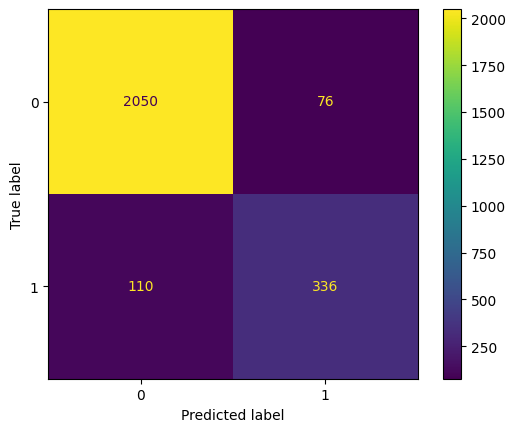

In [139]:
ConfusionMatrixDisplay.from_estimator(grid_search, X_test, y_test)

In [143]:
feature_importances = pd.Series(
    grid_search.best_estimator_["clf"].feature_importances_,
    index=grid_search.best_estimator_["prep"].get_feature_names_out(X_train.columns),
)

feature_importances.sort_values(ascending=False, inplace=True)
feature_importances.head(20)

s_intereses              3429
vinculacion              3246
puntaje_data             3197
ctasahorros              2991
curtotalingresos         2610
valorgarantia            2525
v_cuota                  2398
s_capital                2372
aportes                  2047
edad                     1964
v_prestamo               1642
curtotalegresos          1601
plazo                    1427
actualizacion             264
tipoasociado              262
sexo                      187
intestrato_2.0            108
intestrato_3.0             90
actividadeconomica_21      78
actividadeconomica_24      53
dtype: int32

In [147]:
def objective(trial):
    param = {
        "clf_objective": "binary",
        "clf_class_weight": "balanced",
        "clf_metric": "binary_logloss",
        "clf_lambda_l1": trial.suggest_float("clf_lambda_l1", 1e-8, 10.0, log=True),
        "clf_lambda_l2": trial.suggest_float("clf_lambda_l2", 1e-8, 10.0, log=True),
        "clf_num_leaves": trial.suggest_int("clf_num_leaves", 50, 500),
        "clf_feature_fraction": trial.suggest_float("clf_feature_fraction", 0.4, 1.0),
        "clf_bagging_fraction": trial.suggest_float("clf_bagging_fraction", 0.4, 1.0),
        "clf_bagging_freq": trial.suggest_int("clf_bagging_freq", 1, 7),
        "clf_min_child_samples": trial.suggest_int("clf_min_child_samples", 5, 100),
        "clf_learning_rate": trial.suggest_float(
            "clf_learning_rate", 0.01, 0.3, log=True
        ),
        "clf_colsample_bytree": trial.suggest_float("clf_colsample_bytree", 0.5, 1.0),
        "clf_scale_pos_weight": trial.suggest_float("clf_scale_pos_weight", 1, 10),
    }

    model = Pipeline(
        [
            ("prep", TableVectorizer()),
            ("clf", LGBMClassifier(**param, random_state=1)),
        ]
    )

    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    f1 = f1_score(y_test, preds.round())

    return f1


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)
print(
    f"Best trial: {study.best_trial.value:.3f} with params: {study.best_trial.params}"
)

[I 2026-02-25 17:12:10,320] A new study created in memory with name: no-name-8784502b-9917-46aa-96f1-b7787b9c3e28


[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown parameter: clf_class_weight
[LightGBM] [Warning] Unknown parameter: clf_metric
[LightGBM] [Warning] Unknown parameter: clf_colsample_bytree
[LightGBM] [Warning] Unknown parameter: clf_scale_pos_weight
[LightGBM] [Warning] Unknown parameter: clf_lambda_l1
[LightGBM] [Warning] Unknown parameter: clf_feature_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_freq
[LightGBM] [Warning] Unknown parameter: clf_min_child_samples
[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown para

[I 2026-02-25 17:12:11,312] Trial 0 finished with value: 0.7769607843137255 and parameters: {'clf_lambda_l1': 3.086942343631516e-07, 'clf_lambda_l2': 0.003650220999888706, 'clf_num_leaves': 138, 'clf_feature_fraction': 0.8037514786573294, 'clf_bagging_fraction': 0.9265555672777152, 'clf_bagging_freq': 7, 'clf_min_child_samples': 90, 'clf_learning_rate': 0.10575280835018502, 'clf_colsample_bytree': 0.6936547536775388, 'clf_scale_pos_weight': 6.843959455182498}. Best is trial 0 with value: 0.7769607843137255.


[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown parameter: clf_class_weight
[LightGBM] [Warning] Unknown parameter: clf_metric
[LightGBM] [Warning] Unknown parameter: clf_colsample_bytree
[LightGBM] [Warning] Unknown parameter: clf_scale_pos_weight
[LightGBM] [Warning] Unknown parameter: clf_lambda_l1
[LightGBM] [Warning] Unknown parameter: clf_feature_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_freq
[LightGBM] [Warning] Unknown parameter: clf_min_child_samples
[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown para

[I 2026-02-25 17:12:12,129] Trial 1 finished with value: 0.7785888077858881 and parameters: {'clf_lambda_l1': 6.724592290122195, 'clf_lambda_l2': 0.000245297424818431, 'clf_num_leaves': 148, 'clf_feature_fraction': 0.43333301465055907, 'clf_bagging_fraction': 0.48075808465708564, 'clf_bagging_freq': 1, 'clf_min_child_samples': 17, 'clf_learning_rate': 0.04868921221618313, 'clf_colsample_bytree': 0.7627734918290607, 'clf_scale_pos_weight': 4.574848580806085}. Best is trial 1 with value: 0.7785888077858881.


[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown parameter: clf_class_weight
[LightGBM] [Warning] Unknown parameter: clf_metric
[LightGBM] [Warning] Unknown parameter: clf_colsample_bytree
[LightGBM] [Warning] Unknown parameter: clf_scale_pos_weight
[LightGBM] [Warning] Unknown parameter: clf_lambda_l1
[LightGBM] [Warning] Unknown parameter: clf_feature_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_freq
[LightGBM] [Warning] Unknown parameter: clf_min_child_samples
[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown para

[I 2026-02-25 17:12:13,137] Trial 2 finished with value: 0.7780487804878049 and parameters: {'clf_lambda_l1': 2.5250652990585835e-08, 'clf_lambda_l2': 0.0006389102284179849, 'clf_num_leaves': 431, 'clf_feature_fraction': 0.8612343296844899, 'clf_bagging_fraction': 0.521963700774762, 'clf_bagging_freq': 3, 'clf_min_child_samples': 43, 'clf_learning_rate': 0.0139187078842944, 'clf_colsample_bytree': 0.7711964259004734, 'clf_scale_pos_weight': 4.630476623362362}. Best is trial 1 with value: 0.7785888077858881.


[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown parameter: clf_class_weight
[LightGBM] [Warning] Unknown parameter: clf_metric
[LightGBM] [Warning] Unknown parameter: clf_colsample_bytree
[LightGBM] [Warning] Unknown parameter: clf_scale_pos_weight
[LightGBM] [Warning] Unknown parameter: clf_lambda_l1
[LightGBM] [Warning] Unknown parameter: clf_feature_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_freq
[LightGBM] [Warning] Unknown parameter: clf_min_child_samples
[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown para

[I 2026-02-25 17:12:13,948] Trial 3 finished with value: 0.7730061349693251 and parameters: {'clf_lambda_l1': 1.423866722172304, 'clf_lambda_l2': 0.039469430108976175, 'clf_num_leaves': 183, 'clf_feature_fraction': 0.5916229367019515, 'clf_bagging_fraction': 0.4281839152326816, 'clf_bagging_freq': 4, 'clf_min_child_samples': 21, 'clf_learning_rate': 0.06715710219451028, 'clf_colsample_bytree': 0.6499987869223907, 'clf_scale_pos_weight': 7.80203288709184}. Best is trial 1 with value: 0.7785888077858881.


[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown parameter: clf_class_weight
[LightGBM] [Warning] Unknown parameter: clf_metric
[LightGBM] [Warning] Unknown parameter: clf_colsample_bytree
[LightGBM] [Warning] Unknown parameter: clf_scale_pos_weight
[LightGBM] [Warning] Unknown parameter: clf_lambda_l1
[LightGBM] [Warning] Unknown parameter: clf_feature_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_freq
[LightGBM] [Warning] Unknown parameter: clf_min_child_samples
[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown para

[I 2026-02-25 17:12:14,742] Trial 4 finished with value: 0.7720588235294118 and parameters: {'clf_lambda_l1': 0.015725666556090995, 'clf_lambda_l2': 7.180138160320128e-08, 'clf_num_leaves': 470, 'clf_feature_fraction': 0.45926911019804745, 'clf_bagging_fraction': 0.8969605433183734, 'clf_bagging_freq': 5, 'clf_min_child_samples': 13, 'clf_learning_rate': 0.03138414083784254, 'clf_colsample_bytree': 0.5723695163015982, 'clf_scale_pos_weight': 2.2081533208420785}. Best is trial 1 with value: 0.7785888077858881.


[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown parameter: clf_class_weight
[LightGBM] [Warning] Unknown parameter: clf_metric
[LightGBM] [Warning] Unknown parameter: clf_colsample_bytree
[LightGBM] [Warning] Unknown parameter: clf_scale_pos_weight
[LightGBM] [Warning] Unknown parameter: clf_lambda_l1
[LightGBM] [Warning] Unknown parameter: clf_feature_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_freq
[LightGBM] [Warning] Unknown parameter: clf_min_child_samples
[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown para

[I 2026-02-25 17:12:15,607] Trial 5 finished with value: 0.7724477244772447 and parameters: {'clf_lambda_l1': 1.6094171718342738e-06, 'clf_lambda_l2': 2.0399723715347863e-06, 'clf_num_leaves': 273, 'clf_feature_fraction': 0.8879419771107946, 'clf_bagging_fraction': 0.4590861072051948, 'clf_bagging_freq': 2, 'clf_min_child_samples': 79, 'clf_learning_rate': 0.26910603888000206, 'clf_colsample_bytree': 0.5961743192970841, 'clf_scale_pos_weight': 6.749878577518177}. Best is trial 1 with value: 0.7785888077858881.


[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown parameter: clf_class_weight
[LightGBM] [Warning] Unknown parameter: clf_metric
[LightGBM] [Warning] Unknown parameter: clf_colsample_bytree
[LightGBM] [Warning] Unknown parameter: clf_scale_pos_weight
[LightGBM] [Warning] Unknown parameter: clf_lambda_l1
[LightGBM] [Warning] Unknown parameter: clf_feature_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_freq
[LightGBM] [Warning] Unknown parameter: clf_min_child_samples
[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown para

[I 2026-02-25 17:12:16,833] Trial 6 finished with value: 0.7783251231527094 and parameters: {'clf_lambda_l1': 2.2414053176485985e-06, 'clf_lambda_l2': 9.7920013822609e-07, 'clf_num_leaves': 351, 'clf_feature_fraction': 0.4651412753410258, 'clf_bagging_fraction': 0.4526257717806215, 'clf_bagging_freq': 7, 'clf_min_child_samples': 84, 'clf_learning_rate': 0.15021717226639902, 'clf_colsample_bytree': 0.984905944634026, 'clf_scale_pos_weight': 2.410721022412409}. Best is trial 1 with value: 0.7785888077858881.


[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown parameter: clf_class_weight
[LightGBM] [Warning] Unknown parameter: clf_metric
[LightGBM] [Warning] Unknown parameter: clf_colsample_bytree
[LightGBM] [Warning] Unknown parameter: clf_scale_pos_weight
[LightGBM] [Warning] Unknown parameter: clf_lambda_l1
[LightGBM] [Warning] Unknown parameter: clf_feature_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_freq
[LightGBM] [Warning] Unknown parameter: clf_min_child_samples
[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown para

[I 2026-02-25 17:12:17,975] Trial 7 finished with value: 0.771712158808933 and parameters: {'clf_lambda_l1': 0.027563744212998766, 'clf_lambda_l2': 0.009384175015343459, 'clf_num_leaves': 52, 'clf_feature_fraction': 0.44225680109928334, 'clf_bagging_fraction': 0.7151083101156324, 'clf_bagging_freq': 2, 'clf_min_child_samples': 14, 'clf_learning_rate': 0.03997337206654328, 'clf_colsample_bytree': 0.9726292855699876, 'clf_scale_pos_weight': 3.5148278410325116}. Best is trial 1 with value: 0.7785888077858881.


[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown parameter: clf_class_weight
[LightGBM] [Warning] Unknown parameter: clf_metric
[LightGBM] [Warning] Unknown parameter: clf_colsample_bytree
[LightGBM] [Warning] Unknown parameter: clf_scale_pos_weight
[LightGBM] [Warning] Unknown parameter: clf_lambda_l1
[LightGBM] [Warning] Unknown parameter: clf_feature_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_freq
[LightGBM] [Warning] Unknown parameter: clf_min_child_samples
[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown para

[I 2026-02-25 17:12:19,097] Trial 8 finished with value: 0.7663782447466008 and parameters: {'clf_lambda_l1': 0.003630945453046098, 'clf_lambda_l2': 2.1194160079184818e-08, 'clf_num_leaves': 94, 'clf_feature_fraction': 0.9614230184930145, 'clf_bagging_fraction': 0.7485833602466475, 'clf_bagging_freq': 3, 'clf_min_child_samples': 95, 'clf_learning_rate': 0.13680489299702048, 'clf_colsample_bytree': 0.7254117288726981, 'clf_scale_pos_weight': 5.284999866519073}. Best is trial 1 with value: 0.7785888077858881.


[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown parameter: clf_class_weight
[LightGBM] [Warning] Unknown parameter: clf_metric
[LightGBM] [Warning] Unknown parameter: clf_colsample_bytree
[LightGBM] [Warning] Unknown parameter: clf_scale_pos_weight
[LightGBM] [Warning] Unknown parameter: clf_lambda_l1
[LightGBM] [Warning] Unknown parameter: clf_feature_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_freq
[LightGBM] [Warning] Unknown parameter: clf_min_child_samples
[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown para

[I 2026-02-25 17:12:20,258] Trial 9 finished with value: 0.772782503037667 and parameters: {'clf_lambda_l1': 0.0006309047934796628, 'clf_lambda_l2': 5.385237198262341e-06, 'clf_num_leaves': 419, 'clf_feature_fraction': 0.6853978392996729, 'clf_bagging_fraction': 0.8742735214990485, 'clf_bagging_freq': 3, 'clf_min_child_samples': 84, 'clf_learning_rate': 0.010464541217137196, 'clf_colsample_bytree': 0.9077713532923989, 'clf_scale_pos_weight': 1.066888038052523}. Best is trial 1 with value: 0.7785888077858881.


[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown parameter: clf_class_weight
[LightGBM] [Warning] Unknown parameter: clf_metric
[LightGBM] [Warning] Unknown parameter: clf_colsample_bytree
[LightGBM] [Warning] Unknown parameter: clf_scale_pos_weight
[LightGBM] [Warning] Unknown parameter: clf_lambda_l1
[LightGBM] [Warning] Unknown parameter: clf_feature_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_freq
[LightGBM] [Warning] Unknown parameter: clf_min_child_samples
[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown para

[I 2026-02-25 17:12:21,557] Trial 10 finished with value: 0.7784577723378213 and parameters: {'clf_lambda_l1': 3.4942125037959113, 'clf_lambda_l2': 2.899406282132894, 'clf_num_leaves': 224, 'clf_feature_fraction': 0.5921158149951121, 'clf_bagging_fraction': 0.6128080845612279, 'clf_bagging_freq': 1, 'clf_min_child_samples': 39, 'clf_learning_rate': 0.021993352682732146, 'clf_colsample_bytree': 0.831681625290365, 'clf_scale_pos_weight': 9.71156287963869}. Best is trial 1 with value: 0.7785888077858881.


[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown parameter: clf_class_weight
[LightGBM] [Warning] Unknown parameter: clf_metric
[LightGBM] [Warning] Unknown parameter: clf_colsample_bytree
[LightGBM] [Warning] Unknown parameter: clf_scale_pos_weight
[LightGBM] [Warning] Unknown parameter: clf_lambda_l1
[LightGBM] [Warning] Unknown parameter: clf_feature_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_freq
[LightGBM] [Warning] Unknown parameter: clf_min_child_samples
[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown para

[I 2026-02-25 17:12:22,713] Trial 11 finished with value: 0.7620221948212084 and parameters: {'clf_lambda_l1': 6.059137391380545, 'clf_lambda_l2': 3.0541610730442783, 'clf_num_leaves': 230, 'clf_feature_fraction': 0.6012015094785508, 'clf_bagging_fraction': 0.59443464895309, 'clf_bagging_freq': 1, 'clf_min_child_samples': 37, 'clf_learning_rate': 0.023009586915216103, 'clf_colsample_bytree': 0.8284983019117599, 'clf_scale_pos_weight': 9.925360104510254}. Best is trial 1 with value: 0.7785888077858881.


[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown parameter: clf_class_weight
[LightGBM] [Warning] Unknown parameter: clf_metric
[LightGBM] [Warning] Unknown parameter: clf_colsample_bytree
[LightGBM] [Warning] Unknown parameter: clf_scale_pos_weight
[LightGBM] [Warning] Unknown parameter: clf_lambda_l1
[LightGBM] [Warning] Unknown parameter: clf_feature_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_freq
[LightGBM] [Warning] Unknown parameter: clf_min_child_samples
[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown para

[I 2026-02-25 17:12:24,001] Trial 12 finished with value: 0.7731707317073171 and parameters: {'clf_lambda_l1': 0.3689412079338283, 'clf_lambda_l2': 2.1317976181954625, 'clf_num_leaves': 188, 'clf_feature_fraction': 0.571135967785378, 'clf_bagging_fraction': 0.6069426731324548, 'clf_bagging_freq': 1, 'clf_min_child_samples': 61, 'clf_learning_rate': 0.019935259696105437, 'clf_colsample_bytree': 0.8374389103475925, 'clf_scale_pos_weight': 9.702082255671845}. Best is trial 1 with value: 0.7785888077858881.


[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown parameter: clf_class_weight
[LightGBM] [Warning] Unknown parameter: clf_metric
[LightGBM] [Warning] Unknown parameter: clf_colsample_bytree
[LightGBM] [Warning] Unknown parameter: clf_scale_pos_weight
[LightGBM] [Warning] Unknown parameter: clf_lambda_l1
[LightGBM] [Warning] Unknown parameter: clf_feature_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_freq
[LightGBM] [Warning] Unknown parameter: clf_min_child_samples
[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown para

[I 2026-02-25 17:12:25,211] Trial 13 finished with value: 0.7788697788697788 and parameters: {'clf_lambda_l1': 0.16523387389789418, 'clf_lambda_l2': 6.364331554207722e-05, 'clf_num_leaves': 313, 'clf_feature_fraction': 0.7038495034060497, 'clf_bagging_fraction': 0.6153629501445568, 'clf_bagging_freq': 1, 'clf_min_child_samples': 33, 'clf_learning_rate': 0.058545410293048765, 'clf_colsample_bytree': 0.8113889325007249, 'clf_scale_pos_weight': 8.17247187057474}. Best is trial 13 with value: 0.7788697788697788.


[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown parameter: clf_class_weight
[LightGBM] [Warning] Unknown parameter: clf_metric
[LightGBM] [Warning] Unknown parameter: clf_colsample_bytree
[LightGBM] [Warning] Unknown parameter: clf_scale_pos_weight
[LightGBM] [Warning] Unknown parameter: clf_lambda_l1
[LightGBM] [Warning] Unknown parameter: clf_feature_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_freq
[LightGBM] [Warning] Unknown parameter: clf_min_child_samples
[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown para

[I 2026-02-25 17:12:26,550] Trial 14 finished with value: 0.7737226277372263 and parameters: {'clf_lambda_l1': 0.14499279249903418, 'clf_lambda_l2': 8.115422279190297e-05, 'clf_num_leaves': 333, 'clf_feature_fraction': 0.7097557600673094, 'clf_bagging_fraction': 0.5381724961128532, 'clf_bagging_freq': 5, 'clf_min_child_samples': 28, 'clf_learning_rate': 0.06254788443899456, 'clf_colsample_bytree': 0.7708210877110696, 'clf_scale_pos_weight': 7.721912597638921}. Best is trial 13 with value: 0.7788697788697788.


[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown parameter: clf_class_weight
[LightGBM] [Warning] Unknown parameter: clf_metric
[LightGBM] [Warning] Unknown parameter: clf_colsample_bytree
[LightGBM] [Warning] Unknown parameter: clf_scale_pos_weight
[LightGBM] [Warning] Unknown parameter: clf_lambda_l1
[LightGBM] [Warning] Unknown parameter: clf_feature_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_freq
[LightGBM] [Warning] Unknown parameter: clf_min_child_samples
[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown para

[I 2026-02-25 17:12:27,753] Trial 15 finished with value: 0.7692307692307693 and parameters: {'clf_lambda_l1': 4.304695139207111e-05, 'clf_lambda_l2': 7.151152418521738e-05, 'clf_num_leaves': 351, 'clf_feature_fraction': 0.7111735139407841, 'clf_bagging_fraction': 0.7929632135687438, 'clf_bagging_freq': 2, 'clf_min_child_samples': 55, 'clf_learning_rate': 0.04616359184073141, 'clf_colsample_bytree': 0.5220689136518838, 'clf_scale_pos_weight': 4.222247129654243}. Best is trial 13 with value: 0.7788697788697788.


[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown parameter: clf_class_weight
[LightGBM] [Warning] Unknown parameter: clf_metric
[LightGBM] [Warning] Unknown parameter: clf_colsample_bytree
[LightGBM] [Warning] Unknown parameter: clf_scale_pos_weight
[LightGBM] [Warning] Unknown parameter: clf_lambda_l1
[LightGBM] [Warning] Unknown parameter: clf_feature_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_freq
[LightGBM] [Warning] Unknown parameter: clf_min_child_samples
[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown para

[I 2026-02-25 17:12:28,934] Trial 16 finished with value: 0.7773677736777368 and parameters: {'clf_lambda_l1': 0.16662464363803203, 'clf_lambda_l2': 2.0884058149402145e-05, 'clf_num_leaves': 291, 'clf_feature_fraction': 0.7816195027986043, 'clf_bagging_fraction': 0.649651895581415, 'clf_bagging_freq': 1, 'clf_min_child_samples': 5, 'clf_learning_rate': 0.09396256025131308, 'clf_colsample_bytree': 0.8877057346953665, 'clf_scale_pos_weight': 5.87182807405809}. Best is trial 13 with value: 0.7788697788697788.


[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown parameter: clf_class_weight
[LightGBM] [Warning] Unknown parameter: clf_metric
[LightGBM] [Warning] Unknown parameter: clf_colsample_bytree
[LightGBM] [Warning] Unknown parameter: clf_scale_pos_weight
[LightGBM] [Warning] Unknown parameter: clf_lambda_l1
[LightGBM] [Warning] Unknown parameter: clf_feature_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_freq
[LightGBM] [Warning] Unknown parameter: clf_min_child_samples
[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown para

[I 2026-02-25 17:12:30,108] Trial 17 finished with value: 0.7771010962241169 and parameters: {'clf_lambda_l1': 8.803810316116353, 'clf_lambda_l2': 0.10609461205049868, 'clf_num_leaves': 147, 'clf_feature_fraction': 0.40495062838445745, 'clf_bagging_fraction': 0.5299491147974036, 'clf_bagging_freq': 2, 'clf_min_child_samples': 28, 'clf_learning_rate': 0.07963022487753393, 'clf_colsample_bytree': 0.6598871109153789, 'clf_scale_pos_weight': 8.582073396513506}. Best is trial 13 with value: 0.7788697788697788.


[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown parameter: clf_class_weight
[LightGBM] [Warning] Unknown parameter: clf_metric
[LightGBM] [Warning] Unknown parameter: clf_colsample_bytree
[LightGBM] [Warning] Unknown parameter: clf_scale_pos_weight
[LightGBM] [Warning] Unknown parameter: clf_lambda_l1
[LightGBM] [Warning] Unknown parameter: clf_feature_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_freq
[LightGBM] [Warning] Unknown parameter: clf_min_child_samples
[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown para

[I 2026-02-25 17:12:31,274] Trial 18 finished with value: 0.7641277641277642 and parameters: {'clf_lambda_l1': 0.00017988037803386313, 'clf_lambda_l2': 0.000851717058817853, 'clf_num_leaves': 297, 'clf_feature_fraction': 0.5168050371823425, 'clf_bagging_fraction': 0.8070109446042563, 'clf_bagging_freq': 4, 'clf_min_child_samples': 62, 'clf_learning_rate': 0.03395088589982486, 'clf_colsample_bytree': 0.7809499547939287, 'clf_scale_pos_weight': 6.111155046776659}. Best is trial 13 with value: 0.7788697788697788.


[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown parameter: clf_class_weight
[LightGBM] [Warning] Unknown parameter: clf_metric
[LightGBM] [Warning] Unknown parameter: clf_colsample_bytree
[LightGBM] [Warning] Unknown parameter: clf_scale_pos_weight
[LightGBM] [Warning] Unknown parameter: clf_lambda_l1
[LightGBM] [Warning] Unknown parameter: clf_feature_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_freq
[LightGBM] [Warning] Unknown parameter: clf_min_child_samples
[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown para

[I 2026-02-25 17:12:32,701] Trial 19 finished with value: 0.7931456548347613 and parameters: {'clf_lambda_l1': 0.013297359210547801, 'clf_lambda_l2': 4.7319915528998e-07, 'clf_num_leaves': 234, 'clf_feature_fraction': 0.7706251872493144, 'clf_bagging_fraction': 0.6759957293274383, 'clf_bagging_freq': 6, 'clf_min_child_samples': 47, 'clf_learning_rate': 0.23528869179810669, 'clf_colsample_bytree': 0.9246175836074484, 'clf_scale_pos_weight': 3.475033106730462}. Best is trial 19 with value: 0.7931456548347613.


[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown parameter: clf_class_weight
[LightGBM] [Warning] Unknown parameter: clf_metric
[LightGBM] [Warning] Unknown parameter: clf_colsample_bytree
[LightGBM] [Warning] Unknown parameter: clf_scale_pos_weight
[LightGBM] [Warning] Unknown parameter: clf_lambda_l1
[LightGBM] [Warning] Unknown parameter: clf_feature_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_freq
[LightGBM] [Warning] Unknown parameter: clf_min_child_samples
[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown para

[I 2026-02-25 17:12:34,011] Trial 20 finished with value: 0.7730061349693251 and parameters: {'clf_lambda_l1': 0.0026134669049707126, 'clf_lambda_l2': 2.369464840626051e-07, 'clf_num_leaves': 396, 'clf_feature_fraction': 0.7650403515736455, 'clf_bagging_fraction': 0.6708484689996931, 'clf_bagging_freq': 6, 'clf_min_child_samples': 70, 'clf_learning_rate': 0.20165691148190232, 'clf_colsample_bytree': 0.9271328710434625, 'clf_scale_pos_weight': 2.9683264525119957}. Best is trial 19 with value: 0.7931456548347613.


[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown parameter: clf_class_weight
[LightGBM] [Warning] Unknown parameter: clf_metric
[LightGBM] [Warning] Unknown parameter: clf_colsample_bytree
[LightGBM] [Warning] Unknown parameter: clf_scale_pos_weight
[LightGBM] [Warning] Unknown parameter: clf_lambda_l1
[LightGBM] [Warning] Unknown parameter: clf_feature_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_freq
[LightGBM] [Warning] Unknown parameter: clf_min_child_samples
[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown para

[I 2026-02-25 17:12:35,302] Trial 21 finished with value: 0.7692307692307693 and parameters: {'clf_lambda_l1': 0.02222807385425725, 'clf_lambda_l2': 1.1690870629449627e-05, 'clf_num_leaves': 242, 'clf_feature_fraction': 0.6464559540905293, 'clf_bagging_fraction': 0.5660932867383827, 'clf_bagging_freq': 6, 'clf_min_child_samples': 49, 'clf_learning_rate': 0.05230645105109985, 'clf_colsample_bytree': 0.8597687017360396, 'clf_scale_pos_weight': 4.340115271277504}. Best is trial 19 with value: 0.7931456548347613.


[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown parameter: clf_class_weight
[LightGBM] [Warning] Unknown parameter: clf_metric
[LightGBM] [Warning] Unknown parameter: clf_colsample_bytree
[LightGBM] [Warning] Unknown parameter: clf_scale_pos_weight
[LightGBM] [Warning] Unknown parameter: clf_lambda_l1
[LightGBM] [Warning] Unknown parameter: clf_feature_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_freq
[LightGBM] [Warning] Unknown parameter: clf_min_child_samples
[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown para

[I 2026-02-25 17:12:36,486] Trial 22 finished with value: 0.7815533980582524 and parameters: {'clf_lambda_l1': 0.6330951429429321, 'clf_lambda_l2': 0.00017688565985607115, 'clf_num_leaves': 172, 'clf_feature_fraction': 0.8373111734147195, 'clf_bagging_fraction': 0.984595220279955, 'clf_bagging_freq': 6, 'clf_min_child_samples': 30, 'clf_learning_rate': 0.23112903970479454, 'clf_colsample_bytree': 0.9359296681622679, 'clf_scale_pos_weight': 5.053729735100924}. Best is trial 19 with value: 0.7931456548347613.


[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown parameter: clf_class_weight
[LightGBM] [Warning] Unknown parameter: clf_metric
[LightGBM] [Warning] Unknown parameter: clf_colsample_bytree
[LightGBM] [Warning] Unknown parameter: clf_scale_pos_weight
[LightGBM] [Warning] Unknown parameter: clf_lambda_l1
[LightGBM] [Warning] Unknown parameter: clf_feature_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_freq
[LightGBM] [Warning] Unknown parameter: clf_min_child_samples
[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown para

[I 2026-02-25 17:12:37,810] Trial 23 finished with value: 0.7795371498172959 and parameters: {'clf_lambda_l1': 0.6123648376928121, 'clf_lambda_l2': 9.149111496355231e-07, 'clf_num_leaves': 193, 'clf_feature_fraction': 0.8568763718422129, 'clf_bagging_fraction': 0.8395249721189901, 'clf_bagging_freq': 6, 'clf_min_child_samples': 34, 'clf_learning_rate': 0.28646635437587253, 'clf_colsample_bytree': 0.9300519353528722, 'clf_scale_pos_weight': 3.4969915605594837}. Best is trial 19 with value: 0.7931456548347613.


[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown parameter: clf_class_weight
[LightGBM] [Warning] Unknown parameter: clf_metric
[LightGBM] [Warning] Unknown parameter: clf_colsample_bytree
[LightGBM] [Warning] Unknown parameter: clf_scale_pos_weight
[LightGBM] [Warning] Unknown parameter: clf_lambda_l1
[LightGBM] [Warning] Unknown parameter: clf_feature_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_freq
[LightGBM] [Warning] Unknown parameter: clf_min_child_samples
[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown para

[I 2026-02-25 17:12:39,010] Trial 24 finished with value: 0.7699876998769988 and parameters: {'clf_lambda_l1': 0.7125735012392211, 'clf_lambda_l2': 4.1632071991658216e-07, 'clf_num_leaves': 184, 'clf_feature_fraction': 0.9941152266018951, 'clf_bagging_fraction': 0.949995209472414, 'clf_bagging_freq': 6, 'clf_min_child_samples': 47, 'clf_learning_rate': 0.2673489970848337, 'clf_colsample_bytree': 0.9444342268443963, 'clf_scale_pos_weight': 3.4779971112374226}. Best is trial 19 with value: 0.7931456548347613.


[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown parameter: clf_class_weight
[LightGBM] [Warning] Unknown parameter: clf_metric
[LightGBM] [Warning] Unknown parameter: clf_colsample_bytree
[LightGBM] [Warning] Unknown parameter: clf_scale_pos_weight
[LightGBM] [Warning] Unknown parameter: clf_lambda_l1
[LightGBM] [Warning] Unknown parameter: clf_feature_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_freq
[LightGBM] [Warning] Unknown parameter: clf_min_child_samples
[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown para

[I 2026-02-25 17:12:40,348] Trial 25 finished with value: 0.775609756097561 and parameters: {'clf_lambda_l1': 0.046402416522409645, 'clf_lambda_l2': 1.5317905463638464e-08, 'clf_num_leaves': 258, 'clf_feature_fraction': 0.8936177250462977, 'clf_bagging_fraction': 0.9820534492629498, 'clf_bagging_freq': 5, 'clf_min_child_samples': 28, 'clf_learning_rate': 0.19777434346259543, 'clf_colsample_bytree': 0.9927466052534983, 'clf_scale_pos_weight': 1.5893541962397488}. Best is trial 19 with value: 0.7931456548347613.


[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown parameter: clf_class_weight
[LightGBM] [Warning] Unknown parameter: clf_metric
[LightGBM] [Warning] Unknown parameter: clf_colsample_bytree
[LightGBM] [Warning] Unknown parameter: clf_scale_pos_weight
[LightGBM] [Warning] Unknown parameter: clf_lambda_l1
[LightGBM] [Warning] Unknown parameter: clf_feature_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_freq
[LightGBM] [Warning] Unknown parameter: clf_min_child_samples
[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown para

[I 2026-02-25 17:12:41,652] Trial 26 finished with value: 0.770935960591133 and parameters: {'clf_lambda_l1': 0.005287937078270979, 'clf_lambda_l2': 1.0434733896787053e-07, 'clf_num_leaves': 100, 'clf_feature_fraction': 0.8296846045266357, 'clf_bagging_fraction': 0.8507186134463307, 'clf_bagging_freq': 7, 'clf_min_child_samples': 43, 'clf_learning_rate': 0.1996716584790341, 'clf_colsample_bytree': 0.8708165660215741, 'clf_scale_pos_weight': 3.637977364173192}. Best is trial 19 with value: 0.7931456548347613.


[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown parameter: clf_class_weight
[LightGBM] [Warning] Unknown parameter: clf_metric
[LightGBM] [Warning] Unknown parameter: clf_colsample_bytree
[LightGBM] [Warning] Unknown parameter: clf_scale_pos_weight
[LightGBM] [Warning] Unknown parameter: clf_lambda_l1
[LightGBM] [Warning] Unknown parameter: clf_feature_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_freq
[LightGBM] [Warning] Unknown parameter: clf_min_child_samples
[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown para

[I 2026-02-25 17:12:43,357] Trial 27 finished with value: 0.7764127764127764 and parameters: {'clf_lambda_l1': 0.9823882588062968, 'clf_lambda_l2': 1.8012182059673854e-06, 'clf_num_leaves': 213, 'clf_feature_fraction': 0.9368919002735976, 'clf_bagging_fraction': 0.991680501716542, 'clf_bagging_freq': 6, 'clf_min_child_samples': 59, 'clf_learning_rate': 0.29746674219696706, 'clf_colsample_bytree': 0.9328082090564125, 'clf_scale_pos_weight': 5.181992269063589}. Best is trial 19 with value: 0.7931456548347613.


[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown parameter: clf_class_weight
[LightGBM] [Warning] Unknown parameter: clf_metric
[LightGBM] [Warning] Unknown parameter: clf_colsample_bytree
[LightGBM] [Warning] Unknown parameter: clf_scale_pos_weight
[LightGBM] [Warning] Unknown parameter: clf_lambda_l1
[LightGBM] [Warning] Unknown parameter: clf_feature_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_freq
[LightGBM] [Warning] Unknown parameter: clf_min_child_samples
[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown para

[I 2026-02-25 17:12:44,553] Trial 28 finished with value: 0.769041769041769 and parameters: {'clf_lambda_l1': 0.0005067765359400423, 'clf_lambda_l2': 6.500141963857116e-08, 'clf_num_leaves': 113, 'clf_feature_fraction': 0.7572082962913367, 'clf_bagging_fraction': 0.8075968898823064, 'clf_bagging_freq': 5, 'clf_min_child_samples': 68, 'clf_learning_rate': 0.1390032266631296, 'clf_colsample_bytree': 0.9602238703501679, 'clf_scale_pos_weight': 3.0690431550350654}. Best is trial 19 with value: 0.7931456548347613.


[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown parameter: clf_class_weight
[LightGBM] [Warning] Unknown parameter: clf_metric
[LightGBM] [Warning] Unknown parameter: clf_colsample_bytree
[LightGBM] [Warning] Unknown parameter: clf_scale_pos_weight
[LightGBM] [Warning] Unknown parameter: clf_lambda_l1
[LightGBM] [Warning] Unknown parameter: clf_feature_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_freq
[LightGBM] [Warning] Unknown parameter: clf_min_child_samples
[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown para

[I 2026-02-25 17:12:45,864] Trial 29 finished with value: 0.772782503037667 and parameters: {'clf_lambda_l1': 3.629416041845236e-05, 'clf_lambda_l2': 5.559455415489922e-06, 'clf_num_leaves': 153, 'clf_feature_fraction': 0.817603234276376, 'clf_bagging_fraction': 0.9317922153877245, 'clf_bagging_freq': 7, 'clf_min_child_samples': 22, 'clf_learning_rate': 0.10876718316622383, 'clf_colsample_bytree': 0.8937701996526352, 'clf_scale_pos_weight': 6.492986251979602}. Best is trial 19 with value: 0.7931456548347613.


[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown parameter: clf_class_weight
[LightGBM] [Warning] Unknown parameter: clf_metric
[LightGBM] [Warning] Unknown parameter: clf_colsample_bytree
[LightGBM] [Warning] Unknown parameter: clf_scale_pos_weight
[LightGBM] [Warning] Unknown parameter: clf_lambda_l1
[LightGBM] [Warning] Unknown parameter: clf_feature_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_freq
[LightGBM] [Warning] Unknown parameter: clf_min_child_samples
[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown para

[I 2026-02-25 17:12:47,164] Trial 30 finished with value: 0.7731707317073171 and parameters: {'clf_lambda_l1': 0.043230756815070784, 'clf_lambda_l2': 0.007958168779576705, 'clf_num_leaves': 63, 'clf_feature_fraction': 0.853233106634672, 'clf_bagging_fraction': 0.705897159016578, 'clf_bagging_freq': 6, 'clf_min_child_samples': 52, 'clf_learning_rate': 0.22025439423931414, 'clf_colsample_bytree': 0.9254766234112379, 'clf_scale_pos_weight': 2.271908146400429}. Best is trial 19 with value: 0.7931456548347613.


[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown parameter: clf_class_weight
[LightGBM] [Warning] Unknown parameter: clf_metric
[LightGBM] [Warning] Unknown parameter: clf_colsample_bytree
[LightGBM] [Warning] Unknown parameter: clf_scale_pos_weight
[LightGBM] [Warning] Unknown parameter: clf_lambda_l1
[LightGBM] [Warning] Unknown parameter: clf_feature_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_freq
[LightGBM] [Warning] Unknown parameter: clf_min_child_samples
[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown para

[I 2026-02-25 17:12:48,678] Trial 31 finished with value: 0.7652811735941321 and parameters: {'clf_lambda_l1': 0.13473746100738732, 'clf_lambda_l2': 2.8193337934744294e-05, 'clf_num_leaves': 316, 'clf_feature_fraction': 0.7564489798430831, 'clf_bagging_fraction': 0.7583839535870249, 'clf_bagging_freq': 4, 'clf_min_child_samples': 33, 'clf_learning_rate': 0.16310501104403546, 'clf_colsample_bytree': 0.8006128179443277, 'clf_scale_pos_weight': 7.635136103045286}. Best is trial 19 with value: 0.7931456548347613.


[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown parameter: clf_class_weight
[LightGBM] [Warning] Unknown parameter: clf_metric
[LightGBM] [Warning] Unknown parameter: clf_colsample_bytree
[LightGBM] [Warning] Unknown parameter: clf_scale_pos_weight
[LightGBM] [Warning] Unknown parameter: clf_lambda_l1
[LightGBM] [Warning] Unknown parameter: clf_feature_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_freq
[LightGBM] [Warning] Unknown parameter: clf_min_child_samples
[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown para

[I 2026-02-25 17:12:49,871] Trial 32 finished with value: 0.7724477244772447 and parameters: {'clf_lambda_l1': 1.936534408400604, 'clf_lambda_l2': 0.0001703937309238745, 'clf_num_leaves': 191, 'clf_feature_fraction': 0.7957726421176485, 'clf_bagging_fraction': 0.6376528381579663, 'clf_bagging_freq': 7, 'clf_min_child_samples': 35, 'clf_learning_rate': 0.11232807729752455, 'clf_colsample_bytree': 0.9990212276062382, 'clf_scale_pos_weight': 4.790987306352771}. Best is trial 19 with value: 0.7931456548347613.


[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown parameter: clf_class_weight
[LightGBM] [Warning] Unknown parameter: clf_metric
[LightGBM] [Warning] Unknown parameter: clf_colsample_bytree
[LightGBM] [Warning] Unknown parameter: clf_scale_pos_weight
[LightGBM] [Warning] Unknown parameter: clf_lambda_l1
[LightGBM] [Warning] Unknown parameter: clf_feature_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_freq
[LightGBM] [Warning] Unknown parameter: clf_min_child_samples
[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown para

[I 2026-02-25 17:12:51,096] Trial 33 finished with value: 0.7718865598027127 and parameters: {'clf_lambda_l1': 0.3415614047135814, 'clf_lambda_l2': 0.0008750377701007453, 'clf_num_leaves': 255, 'clf_feature_fraction': 0.9092796184248556, 'clf_bagging_fraction': 0.847950363430295, 'clf_bagging_freq': 6, 'clf_min_child_samples': 43, 'clf_learning_rate': 0.21797550099544394, 'clf_colsample_bytree': 0.8618772687593249, 'clf_scale_pos_weight': 3.9275264771707974}. Best is trial 19 with value: 0.7931456548347613.


[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown parameter: clf_class_weight
[LightGBM] [Warning] Unknown parameter: clf_metric
[LightGBM] [Warning] Unknown parameter: clf_colsample_bytree
[LightGBM] [Warning] Unknown parameter: clf_scale_pos_weight
[LightGBM] [Warning] Unknown parameter: clf_lambda_l1
[LightGBM] [Warning] Unknown parameter: clf_feature_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_freq
[LightGBM] [Warning] Unknown parameter: clf_min_child_samples
[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown para

[I 2026-02-25 17:12:52,440] Trial 34 finished with value: 0.7726161369193154 and parameters: {'clf_lambda_l1': 0.008730172150179056, 'clf_lambda_l2': 0.0017635837966609783, 'clf_num_leaves': 161, 'clf_feature_fraction': 0.6689027087405628, 'clf_bagging_fraction': 0.6803034998478362, 'clf_bagging_freq': 5, 'clf_min_child_samples': 24, 'clf_learning_rate': 0.17066331157534584, 'clf_colsample_bytree': 0.7346599958273826, 'clf_scale_pos_weight': 5.671739251045443}. Best is trial 19 with value: 0.7931456548347613.


[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown parameter: clf_class_weight
[LightGBM] [Warning] Unknown parameter: clf_metric
[LightGBM] [Warning] Unknown parameter: clf_colsample_bytree
[LightGBM] [Warning] Unknown parameter: clf_scale_pos_weight
[LightGBM] [Warning] Unknown parameter: clf_lambda_l1
[LightGBM] [Warning] Unknown parameter: clf_feature_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_freq
[LightGBM] [Warning] Unknown parameter: clf_min_child_samples
[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown para

[I 2026-02-25 17:12:53,866] Trial 35 finished with value: 0.7728395061728395 and parameters: {'clf_lambda_l1': 0.07886461991880506, 'clf_lambda_l2': 6.302523846572709e-07, 'clf_num_leaves': 213, 'clf_feature_fraction': 0.7333321873671195, 'clf_bagging_fraction': 0.7432675656828938, 'clf_bagging_freq': 4, 'clf_min_child_samples': 32, 'clf_learning_rate': 0.25419554716695214, 'clf_colsample_bytree': 0.8089875329605991, 'clf_scale_pos_weight': 4.89054013577545}. Best is trial 19 with value: 0.7931456548347613.


[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown parameter: clf_class_weight
[LightGBM] [Warning] Unknown parameter: clf_metric
[LightGBM] [Warning] Unknown parameter: clf_colsample_bytree
[LightGBM] [Warning] Unknown parameter: clf_scale_pos_weight
[LightGBM] [Warning] Unknown parameter: clf_lambda_l1
[LightGBM] [Warning] Unknown parameter: clf_feature_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_freq
[LightGBM] [Warning] Unknown parameter: clf_min_child_samples
[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown para

[I 2026-02-25 17:12:55,053] Trial 36 finished with value: 0.7701711491442543 and parameters: {'clf_lambda_l1': 0.5605163168374331, 'clf_lambda_l2': 0.00023826134248293402, 'clf_num_leaves': 122, 'clf_feature_fraction': 0.8545900872198872, 'clf_bagging_fraction': 0.8980067435630477, 'clf_bagging_freq': 6, 'clf_min_child_samples': 17, 'clf_learning_rate': 0.08132812701601554, 'clf_colsample_bytree': 0.9088183904612632, 'clf_scale_pos_weight': 7.125735631682872}. Best is trial 19 with value: 0.7931456548347613.


[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown parameter: clf_class_weight
[LightGBM] [Warning] Unknown parameter: clf_metric
[LightGBM] [Warning] Unknown parameter: clf_colsample_bytree
[LightGBM] [Warning] Unknown parameter: clf_scale_pos_weight
[LightGBM] [Warning] Unknown parameter: clf_lambda_l1
[LightGBM] [Warning] Unknown parameter: clf_feature_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_freq
[LightGBM] [Warning] Unknown parameter: clf_min_child_samples
[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown para

[I 2026-02-25 17:12:56,257] Trial 37 finished with value: 0.7780487804878049 and parameters: {'clf_lambda_l1': 5.6403339893867514e-08, 'clf_lambda_l2': 5.73396109161342e-06, 'clf_num_leaves': 375, 'clf_feature_fraction': 0.6433427207355624, 'clf_bagging_fraction': 0.48912688147062267, 'clf_bagging_freq': 7, 'clf_min_child_samples': 40, 'clf_learning_rate': 0.1287802653651459, 'clf_colsample_bytree': 0.9614866033718706, 'clf_scale_pos_weight': 8.830113759067672}. Best is trial 19 with value: 0.7931456548347613.


[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown parameter: clf_class_weight
[LightGBM] [Warning] Unknown parameter: clf_metric
[LightGBM] [Warning] Unknown parameter: clf_colsample_bytree
[LightGBM] [Warning] Unknown parameter: clf_scale_pos_weight
[LightGBM] [Warning] Unknown parameter: clf_lambda_l1
[LightGBM] [Warning] Unknown parameter: clf_feature_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_freq
[LightGBM] [Warning] Unknown parameter: clf_min_child_samples
[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown para

[I 2026-02-25 17:12:57,444] Trial 38 finished with value: 0.7785888077858881 and parameters: {'clf_lambda_l1': 1.8823068846084667, 'clf_lambda_l2': 0.06444185663532354, 'clf_num_leaves': 275, 'clf_feature_fraction': 0.8374337491483507, 'clf_bagging_fraction': 0.9615492767571602, 'clf_bagging_freq': 5, 'clf_min_child_samples': 7, 'clf_learning_rate': 0.1723943717141652, 'clf_colsample_bytree': 0.9552713662202916, 'clf_scale_pos_weight': 4.0181369104219105}. Best is trial 19 with value: 0.7931456548347613.


[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown parameter: clf_class_weight
[LightGBM] [Warning] Unknown parameter: clf_metric
[LightGBM] [Warning] Unknown parameter: clf_colsample_bytree
[LightGBM] [Warning] Unknown parameter: clf_scale_pos_weight
[LightGBM] [Warning] Unknown parameter: clf_lambda_l1
[LightGBM] [Warning] Unknown parameter: clf_feature_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_freq
[LightGBM] [Warning] Unknown parameter: clf_min_child_samples
[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown para

[I 2026-02-25 17:12:58,729] Trial 39 finished with value: 0.7728395061728395 and parameters: {'clf_lambda_l1': 0.0013081580025949943, 'clf_lambda_l2': 4.5424568052683604e-05, 'clf_num_leaves': 468, 'clf_feature_fraction': 0.8120277156724043, 'clf_bagging_fraction': 0.9072880179173072, 'clf_bagging_freq': 3, 'clf_min_child_samples': 19, 'clf_learning_rate': 0.24592128832051832, 'clf_colsample_bytree': 0.6936907792497433, 'clf_scale_pos_weight': 2.905143372386547}. Best is trial 19 with value: 0.7931456548347613.


[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown parameter: clf_class_weight
[LightGBM] [Warning] Unknown parameter: clf_metric
[LightGBM] [Warning] Unknown parameter: clf_colsample_bytree
[LightGBM] [Warning] Unknown parameter: clf_scale_pos_weight
[LightGBM] [Warning] Unknown parameter: clf_lambda_l1
[LightGBM] [Warning] Unknown parameter: clf_feature_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_freq
[LightGBM] [Warning] Unknown parameter: clf_min_child_samples
[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown para

[I 2026-02-25 17:12:59,995] Trial 40 finished with value: 0.7705521472392638 and parameters: {'clf_lambda_l1': 0.2503224595955911, 'clf_lambda_l2': 1.4988248450784765e-06, 'clf_num_leaves': 164, 'clf_feature_fraction': 0.918442299172387, 'clf_bagging_fraction': 0.40092032148315765, 'clf_bagging_freq': 6, 'clf_min_child_samples': 47, 'clf_learning_rate': 0.2916367308505893, 'clf_colsample_bytree': 0.8780545520069034, 'clf_scale_pos_weight': 1.8746234376406306}. Best is trial 19 with value: 0.7931456548347613.


[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown parameter: clf_class_weight
[LightGBM] [Warning] Unknown parameter: clf_metric
[LightGBM] [Warning] Unknown parameter: clf_colsample_bytree
[LightGBM] [Warning] Unknown parameter: clf_scale_pos_weight
[LightGBM] [Warning] Unknown parameter: clf_lambda_l1
[LightGBM] [Warning] Unknown parameter: clf_feature_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_freq
[LightGBM] [Warning] Unknown parameter: clf_min_child_samples
[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown para

[I 2026-02-25 17:13:01,286] Trial 41 finished with value: 0.7766990291262136 and parameters: {'clf_lambda_l1': 1.5644917033439236, 'clf_lambda_l2': 0.004433379112109202, 'clf_num_leaves': 202, 'clf_feature_fraction': 0.7283568492331645, 'clf_bagging_fraction': 0.5737899383094287, 'clf_bagging_freq': 2, 'clf_min_child_samples': 12, 'clf_learning_rate': 0.031597842977405095, 'clf_colsample_bytree': 0.7013862065825466, 'clf_scale_pos_weight': 4.686803994770568}. Best is trial 19 with value: 0.7931456548347613.


[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown parameter: clf_class_weight
[LightGBM] [Warning] Unknown parameter: clf_metric
[LightGBM] [Warning] Unknown parameter: clf_colsample_bytree
[LightGBM] [Warning] Unknown parameter: clf_scale_pos_weight
[LightGBM] [Warning] Unknown parameter: clf_lambda_l1
[LightGBM] [Warning] Unknown parameter: clf_feature_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_freq
[LightGBM] [Warning] Unknown parameter: clf_min_child_samples
[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown para

[I 2026-02-25 17:13:02,539] Trial 42 finished with value: 0.7773677736777368 and parameters: {'clf_lambda_l1': 9.912757059550975, 'clf_lambda_l2': 0.00026648844442911623, 'clf_num_leaves': 124, 'clf_feature_fraction': 0.8811667324492896, 'clf_bagging_fraction': 0.4887989271127494, 'clf_bagging_freq': 1, 'clf_min_child_samples': 31, 'clf_learning_rate': 0.0639329401672767, 'clf_colsample_bytree': 0.766281526841563, 'clf_scale_pos_weight': 5.148186730551866}. Best is trial 19 with value: 0.7931456548347613.


[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown parameter: clf_class_weight
[LightGBM] [Warning] Unknown parameter: clf_metric
[LightGBM] [Warning] Unknown parameter: clf_colsample_bytree
[LightGBM] [Warning] Unknown parameter: clf_scale_pos_weight
[LightGBM] [Warning] Unknown parameter: clf_lambda_l1
[LightGBM] [Warning] Unknown parameter: clf_feature_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_freq
[LightGBM] [Warning] Unknown parameter: clf_min_child_samples
[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown para

[I 2026-02-25 17:13:03,717] Trial 43 finished with value: 0.7747524752475248 and parameters: {'clf_lambda_l1': 0.015156329921691327, 'clf_lambda_l2': 1.7631462404318946e-07, 'clf_num_leaves': 170, 'clf_feature_fraction': 0.5206694411711746, 'clf_bagging_fraction': 0.7208973029974498, 'clf_bagging_freq': 1, 'clf_min_child_samples': 23, 'clf_learning_rate': 0.043624321245034375, 'clf_colsample_bytree': 0.6496653711778171, 'clf_scale_pos_weight': 2.6783098978787794}. Best is trial 19 with value: 0.7931456548347613.


[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown parameter: clf_class_weight
[LightGBM] [Warning] Unknown parameter: clf_metric
[LightGBM] [Warning] Unknown parameter: clf_colsample_bytree
[LightGBM] [Warning] Unknown parameter: clf_scale_pos_weight
[LightGBM] [Warning] Unknown parameter: clf_lambda_l1
[LightGBM] [Warning] Unknown parameter: clf_feature_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_freq
[LightGBM] [Warning] Unknown parameter: clf_min_child_samples
[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown para

[I 2026-02-25 17:13:04,909] Trial 44 finished with value: 0.7733333333333333 and parameters: {'clf_lambda_l1': 3.2292100339506753, 'clf_lambda_l2': 0.015777132669989945, 'clf_num_leaves': 72, 'clf_feature_fraction': 0.7893373730158169, 'clf_bagging_fraction': 0.6375007785154722, 'clf_bagging_freq': 3, 'clf_min_child_samples': 11, 'clf_learning_rate': 0.02657960402363233, 'clf_colsample_bytree': 0.8404633050456981, 'clf_scale_pos_weight': 3.3401319518556774}. Best is trial 19 with value: 0.7931456548347613.


[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown parameter: clf_class_weight
[LightGBM] [Warning] Unknown parameter: clf_metric
[LightGBM] [Warning] Unknown parameter: clf_colsample_bytree
[LightGBM] [Warning] Unknown parameter: clf_scale_pos_weight
[LightGBM] [Warning] Unknown parameter: clf_lambda_l1
[LightGBM] [Warning] Unknown parameter: clf_feature_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_freq
[LightGBM] [Warning] Unknown parameter: clf_min_child_samples
[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown para

[I 2026-02-25 17:13:06,217] Trial 45 finished with value: 0.7795371498172959 and parameters: {'clf_lambda_l1': 0.07759573267405381, 'clf_lambda_l2': 0.00014075317865051913, 'clf_num_leaves': 257, 'clf_feature_fraction': 0.6796914344563371, 'clf_bagging_fraction': 0.7830566692218388, 'clf_bagging_freq': 2, 'clf_min_child_samples': 42, 'clf_learning_rate': 0.014643149809162745, 'clf_colsample_bytree': 0.8088662778211406, 'clf_scale_pos_weight': 4.487438887234467}. Best is trial 19 with value: 0.7931456548347613.


[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown parameter: clf_class_weight
[LightGBM] [Warning] Unknown parameter: clf_metric
[LightGBM] [Warning] Unknown parameter: clf_colsample_bytree
[LightGBM] [Warning] Unknown parameter: clf_scale_pos_weight
[LightGBM] [Warning] Unknown parameter: clf_lambda_l1
[LightGBM] [Warning] Unknown parameter: clf_feature_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_freq
[LightGBM] [Warning] Unknown parameter: clf_min_child_samples
[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown para

[I 2026-02-25 17:13:07,442] Trial 46 finished with value: 0.770935960591133 and parameters: {'clf_lambda_l1': 0.0952309301802037, 'clf_lambda_l2': 1.2966150956973141e-05, 'clf_num_leaves': 241, 'clf_feature_fraction': 0.6648864354815056, 'clf_bagging_fraction': 0.8355339298440287, 'clf_bagging_freq': 2, 'clf_min_child_samples': 40, 'clf_learning_rate': 0.016086823382916653, 'clf_colsample_bytree': 0.7964738220822655, 'clf_scale_pos_weight': 4.391076527279233}. Best is trial 19 with value: 0.7931456548347613.


[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown parameter: clf_class_weight
[LightGBM] [Warning] Unknown parameter: clf_metric
[LightGBM] [Warning] Unknown parameter: clf_colsample_bytree
[LightGBM] [Warning] Unknown parameter: clf_scale_pos_weight
[LightGBM] [Warning] Unknown parameter: clf_lambda_l1
[LightGBM] [Warning] Unknown parameter: clf_feature_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_freq
[LightGBM] [Warning] Unknown parameter: clf_min_child_samples
[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown para

[I 2026-02-25 17:13:08,688] Trial 47 finished with value: 0.7701711491442543 and parameters: {'clf_lambda_l1': 0.011539917822800172, 'clf_lambda_l2': 0.00010427562728477593, 'clf_num_leaves': 317, 'clf_feature_fraction': 0.6968814176993522, 'clf_bagging_fraction': 0.7776337120155443, 'clf_bagging_freq': 5, 'clf_min_child_samples': 37, 'clf_learning_rate': 0.010483244727183389, 'clf_colsample_bytree': 0.9044033602673813, 'clf_scale_pos_weight': 3.798551839277815}. Best is trial 19 with value: 0.7931456548347613.


[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown parameter: clf_class_weight
[LightGBM] [Warning] Unknown parameter: clf_metric
[LightGBM] [Warning] Unknown parameter: clf_colsample_bytree
[LightGBM] [Warning] Unknown parameter: clf_scale_pos_weight
[LightGBM] [Warning] Unknown parameter: clf_lambda_l1
[LightGBM] [Warning] Unknown parameter: clf_feature_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_freq
[LightGBM] [Warning] Unknown parameter: clf_min_child_samples
[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown para

[I 2026-02-25 17:13:09,872] Trial 48 finished with value: 0.7771010962241169 and parameters: {'clf_lambda_l1': 0.5309001842353653, 'clf_lambda_l2': 2.9723035511054333e-06, 'clf_num_leaves': 296, 'clf_feature_fraction': 0.6306823582919435, 'clf_bagging_fraction': 0.8743945134106981, 'clf_bagging_freq': 1, 'clf_min_child_samples': 55, 'clf_learning_rate': 0.019032595689500043, 'clf_colsample_bytree': 0.851558104460461, 'clf_scale_pos_weight': 6.3368292383203055}. Best is trial 19 with value: 0.7931456548347613.


[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown parameter: clf_class_weight
[LightGBM] [Warning] Unknown parameter: clf_metric
[LightGBM] [Warning] Unknown parameter: clf_colsample_bytree
[LightGBM] [Warning] Unknown parameter: clf_scale_pos_weight
[LightGBM] [Warning] Unknown parameter: clf_lambda_l1
[LightGBM] [Warning] Unknown parameter: clf_feature_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_freq
[LightGBM] [Warning] Unknown parameter: clf_min_child_samples
[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown para

[I 2026-02-25 17:13:11,297] Trial 49 finished with value: 0.7745098039215687 and parameters: {'clf_lambda_l1': 0.05223678778586321, 'clf_lambda_l2': 0.23063758737022516, 'clf_num_leaves': 270, 'clf_feature_fraction': 0.7244721486257839, 'clf_bagging_fraction': 0.684195941977312, 'clf_bagging_freq': 2, 'clf_min_child_samples': 26, 'clf_learning_rate': 0.03627583858977636, 'clf_colsample_bytree': 0.8185146715115243, 'clf_scale_pos_weight': 5.4218966584578485}. Best is trial 19 with value: 0.7931456548347613.


[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_objective
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown parameter: clf_class_weight
[LightGBM] [Warning] Unknown parameter: clf_metric
[LightGBM] [Warning] Unknown parameter: clf_colsample_bytree
[LightGBM] [Warning] Unknown parameter: clf_scale_pos_weight
[LightGBM] [Warning] Unknown parameter: clf_lambda_l1
[LightGBM] [Warning] Unknown parameter: clf_feature_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_freq
[LightGBM] [Warning] Unknown parameter: clf_min_child_samples
Best trial: 0.793 with params: {'clf_lambda_l1': 0.013297359210547801, 'clf_lambda_l2': 4.7319915528998e-07, 'clf_num_leaves': 234, 'clf_feature_fraction': 0.7706251872493144, 'clf_bagging_fraction': 0.6759957293274383, 'clf_bagging_freq': 6, 'clf_min_ch

In [151]:
pipe

,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,cardinality_threshold,40
,low_cardinality,OneHotEncoder..._output=False)
,high_cardinality,StringEncoder()
,numeric,PassThrough()
,datetime,DatetimeEncoder()
,specific_transformers,()
,drop_null_fraction,1.0


In [154]:
study.best_trial.params

{'clf_lambda_l1': 0.013297359210547801,
 'clf_lambda_l2': 4.7319915528998e-07,
 'clf_num_leaves': 234,
 'clf_feature_fraction': 0.7706251872493144,
 'clf_bagging_fraction': 0.6759957293274383,
 'clf_bagging_freq': 6,
 'clf_min_child_samples': 47,
 'clf_learning_rate': 0.23528869179810669,
 'clf_colsample_bytree': 0.9246175836074484,
 'clf_scale_pos_weight': 3.475033106730462}

In [153]:
pipe.named_steps["clf"].set_params(**study.best_trial.params)
pipe.fit(X_train, y_train)

train_score = f1_score(y_train, pipe.predict(X_train))
test_score = f1_score(y_test, pipe.predict(X_test))
print(f"Train score: {train_score:.2f}")
print(f"Test score: {test_score:.2f}")

[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_lambda_l1
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown parameter: clf_feature_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_freq
[LightGBM] [Warning] Unknown parameter: clf_min_child_samples
[LightGBM] [Warning] Unknown parameter: clf_colsample_bytree
[LightGBM] [Warning] Unknown parameter: clf_scale_pos_weight
[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_lambda_l1
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown parameter: clf_feature_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_freq
[LightGBM] [Warn

In [156]:
print(classification_report(y_test, pipe.predict(X_test)))

[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_lambda_l1
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown parameter: clf_feature_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_freq
[LightGBM] [Warning] Unknown parameter: clf_min_child_samples
[LightGBM] [Warning] Unknown parameter: clf_colsample_bytree
[LightGBM] [Warning] Unknown parameter: clf_scale_pos_weight
              precision    recall  f1-score   support

           0       0.96      0.94      0.95      2126
           1       0.73      0.81      0.77       446

    accuracy                           0.92      2572
   macro avg       0.85      0.87      0.86      2572
weighted avg       0.92      0.92      0.92      2572



[LightGBM] [Warning] Unknown parameter: clf_lambda_l2
[LightGBM] [Warning] Unknown parameter: clf_learning_rate
[LightGBM] [Warning] Unknown parameter: clf_lambda_l1
[LightGBM] [Warning] Unknown parameter: clf_num_leaves
[LightGBM] [Warning] Unknown parameter: clf_feature_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_fraction
[LightGBM] [Warning] Unknown parameter: clf_bagging_freq
[LightGBM] [Warning] Unknown parameter: clf_min_child_samples
[LightGBM] [Warning] Unknown parameter: clf_colsample_bytree
[LightGBM] [Warning] Unknown parameter: clf_scale_pos_weight


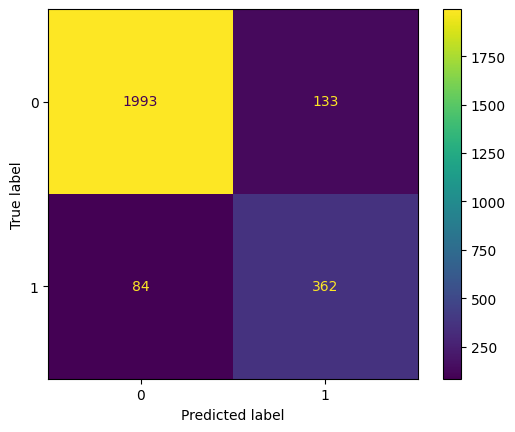

In [157]:
ConfusionMatrixDisplay.from_estimator(pipe, X_test, y_test)

This is the model with the best performance

In [ ]:
import joblib

MODELS_DIR = Path().resolve().parent / "models"

best_skrub = grid_search.best_estimator_
joblib.dump(best_skrub, MODELS_DIR / "lgb_model.joblib")

In [ ]:
# Guardar hiperparámetros del modelo en en un archivo JSON
import json

with open(MODELS_DIR / "lgb_model_params.json", "w") as f:
    json.dump(grid_search.best_params_, f, indent=4)

### Skrub con modelo por defecto y ajuste de hiperparametros

In [ ]:
from sklearn.metrics import f1_score, make_scorer
from sklearn.model_selection import GridSearchCV, StratifiedKFold

pipe = tabular_pipeline("classifier")

param_grid = {
    "histgradientboostingclassifier__learning_rate": [0.1, 0.05, 0.02],
    "histgradientboostingclassifier__max_iter": [200, 400, 800],
    "histgradientboostingclassifier__max_leaf_nodes": [31, 63, 127],
    "histgradientboostingclassifier__min_samples_leaf": [10, 20, 40],
    "histgradientboostingclassifier__l2_regularization": [0.0, 0.1, 1.0],
    "histgradientboostingclassifier__early_stopping": [True],
}

# 3) Métrica y CV (para 5 clases sueles preferir f1_macro)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scorer = make_scorer(f1_score, average="macro")

# 4) Grid search
search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring=scorer,
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=1,
)

search.fit(X_train, y_train)
best_pipe = search.best_estimator_

print("Mejores hiperparámetros:", search.best_params_)
print("Mejor f1_macro (CV):", search.best_score_)

In [ ]:
y_pred = best_pipe.predict(X_test)
print(classification_report(y_test, y_pred, digits=2))

In [ ]:
ConfusionMatrixDisplay.from_estimator(best_pipe, X_test, y_test)

In [ ]:
best_skrub = search.best_estimator_
joblib.dump(best_skrub, MODELS_DIR / "hist_model.joblib")

In [ ]:
with open(MODELS_DIR / "hist_model_params.json", "w") as f:
    json.dump(search.best_params_, f, indent=4)

# Skrub with other models

## Skrub + xgbost

In [ ]:
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
model_xgb = XGBClassifier(
    grow_policy="lossguide",
    tree_method="hist",
    enable_categorical=True,  # Allows categorical variables to be handled directly
)

# This is the pipeline with TableVectorizer and XGBClassifier
pipe = Pipeline(
    [
        ("prep", TableVectorizer()),  # detecta y transforma numéricos/categóricos
        ("clf", model_xgb),
    ]
)

# This is the list of hyperparameters to tune
param_distributions = {
    "clf__max_depth": randint(3, 15),
    "clf__learning_rate": loguniform(0.01, 0.3),
    "clf__n_estimators": randint(1, 500),
    "clf__subsample": uniform(0.5, 0.5),  # de 0.5 a 1.0
    "clf__colsample_bytree": uniform(0.5, 0.5),
    "clf__reg_alpha": loguniform(1e-3, 10),
    "clf__reg_lambda": loguniform(1e-3, 10),
    "clf__max_delta_step": randint(0, 10),
    "clf__gamma": uniform(0, 2),
    "clf__min_child_weight": randint(5, 10),
    "clf__scale_pos_weight": uniform(
        1, 10
    ),  # Con este hiperparámetro se balancean las clases
}

grid_search_xgb = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_distributions,
    n_iter=50,
    scoring="f1_weighted",
)
grid_search_xgb.fit(
    X_train,
    y_train,
)

test_score = f1_score(y_test, grid_search_xgb.predict(X_test), average="weighted")
print(
    f"Best score: {grid_search_xgb.best_score_:.3f} with {grid_search_xgb.best_params_}"
)
print(f"Test score: {test_score:.3f}")

In [ ]:
best_pipe_xgb = grid_search_xgb.best_estimator_

y_pred = best_pipe_xgb.predict(X_test)
print(classification_report(y_test, y_pred, digits=2))

In [ ]:
ConfusionMatrixDisplay.from_estimator(best_pipe_xgb, X_test, y_test)

In [ ]:
joblib.dump(best_pipe_xgb, MODELS_DIR / "xgb_model.joblib")

In [ ]:
with open(MODELS_DIR / "xgb_model_params.json", "w") as f:
    json.dump(grid_search_xgb.best_params_, f, indent=4)

## Skrub + random forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings("ignore")
rfc_model = RandomForestClassifier(
    class_weight="balanced"  # Hace balanceo de clases
)

# This is the pipeline with TableVectorizer and XGBClassifier
pipe = Pipeline(
    [
        ("prep", TableVectorizer()),  # detecta y transforma numéricos/categóricos
        ("classifier", rfc_model),
    ]
)

# This is the list of hyperparameters to tune
param_distributions = {
    "classifier__n_estimators": randint(50, 500),
    "classifier__max_depth": randint(3, 15),
    "classifier__min_samples_split": randint(2, 20),
    "classifier__min_samples_leaf": randint(1, 20),
    "classifier__max_features": ["auto", "sqrt", "log2", None],
    "classifier__bootstrap": [True, False],
    "classifier__criterion": ["gini", "entropy", "log_loss"],
}

grid_search_rfc = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_distributions,
    n_iter=50,
    scoring="f1_weighted",
)
grid_search_rfc.fit(
    X_train,
    y_train,
)

test_score = f1_score(y_test, grid_search_rfc.predict(X_test), average="weighted")
print(
    f"Best score: {grid_search_rfc.best_score_:.3f} with {grid_search_rfc.best_params_}"
)
print(f"Test score: {test_score:.3f}")

In [ ]:
best_pipe_rfc = grid_search_rfc.best_estimator_

y_pred = best_pipe_rfc.predict(X_test)
print(classification_report(y_test, y_pred, digits=3))

In [ ]:
ConfusionMatrixDisplay.from_estimator(best_pipe_rfc, X_test, y_test)

In [ ]:
joblib.dump(best_pipe_rfc, MODELS_DIR / "rfc_model.joblib")

In [ ]:
with open(MODELS_DIR / "rfc_model_params.json", "w") as f:
    json.dump(grid_search_rfc.best_params_, f, indent=4)

## Skrub + logistic regresion

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

# This is the pipeline with TableVectorizer and XGBClassifier
pipe = Pipeline(
    [
        ("prep", TableVectorizer()),  # detecta y transforma numéricos/categóricos
        (
            "scaler",
            StandardScaler(with_mean=False),
        ),  # StandardScaler para datos dispersos
        (
            "classifier",
            LogisticRegression(
                solver="liblinear", max_iter=1000, class_weight="balanced"
            ),
        ),
    ]
)

# This is the list of hyperparameters to tune
param_distributions = {
    "classifier__penalty": ["l1", "l2"],
    "classifier__C": loguniform(1e-3, 1e3),
}

grid_search_lrc = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_distributions,
    n_iter=50,
    scoring="f1_weighted",
)
grid_search_lrc.fit(X_train, y_train)

test_score = f1_score(y_test, grid_search_lrc.predict(X_test), average="weighted")
print(
    f"Best score: {grid_search_lrc.best_score_:.3f} with {grid_search_lrc.best_params_}"
)
print(f"Test score: {test_score:.3f}")

In [ ]:
best_pipe_lrc = grid_search_lrc.best_estimator_
y_pred = best_pipe_lrc.predict(X_test)
print(classification_report(y_test, y_pred, digits=3))

In [ ]:
ConfusionMatrixDisplay.from_estimator(best_pipe_lrc, X_test, y_test)

In [ ]:
joblib.dump(best_pipe_lrc, "best_pipe_lrc.joblib")
# best_skrub=joblib.load("best_skrub_model.joblib")

## Skrub + logistic regresor classifier + balance de clases

In [ ]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler

warnings.filterwarnings("ignore")

# This is the pipeline with TableVectorizer and XGBClassifier
pipe = ImbPipeline(
    [
        ("prep", TableVectorizer()),  # detecta y transforma numéricos/categóricos
        (
            "scaler",
            StandardScaler(with_mean=False),
        ),  # StandardScaler para datos dispersos
        (
            "undersampling",
            RandomUnderSampler(sampling_strategy="majority", random_state=1),
        ),
        (
            "classifier",
            LogisticRegression(
                solver="liblinear", max_iter=1000, class_weight="balanced"
            ),
        ),
    ]
)

# This is the list of hyperparameters to tune
param_distributions = {
    "classifier__penalty": ["l1", "l2"],
    "classifier__C": loguniform(1e-3, 1e3),
}

grid_search_lrc_bal = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_distributions,
    n_iter=50,
    scoring="f1_weighted",
)
grid_search_lrc_bal.fit(
    X_train,
    y_train,
)

test_score = f1_score(y_test, grid_search_lrc_bal.predict(X_test), average="weighted")
print(
    f"Best score: {grid_search_lrc_bal.best_score_:.3f} with {grid_search_lrc_bal.best_params_}"
)
print(f"Test score: {test_score:.3f}")

In [ ]:
best_pipe_lrc_bal = grid_search_lrc_bal.best_estimator_
y_pred = best_pipe_lrc_bal.predict(X_test)
print(classification_report(y_test, y_pred, digits=3))

In [ ]:
ConfusionMatrixDisplay.from_estimator(best_pipe_lrc_bal, X_test, y_test)

In [ ]:
joblib.dump(best_pipe_lrc_bal, "best_pipe_lrc_bal.joblib")
# best_skrub=joblib.load("best_skrub_model.joblib")

## Skrub + Multilayer Perceptron

In [ ]:
from sklearn.neural_network import MLPClassifier

warnings.filterwarnings("ignore")

# This is the pipeline with TableVectorizer and XGBClassifier
pipe = Pipeline(
    [
        ("prep", TableVectorizer()),  # detecta y transforma numéricos/categóricos
        (
            "scaler",
            StandardScaler(with_mean=False),
        ),  # StandardScaler para datos dispersos
        (
            "classifier",
            MLPClassifier(
                learning_rate_init=0.001, hidden_layer_sizes=[10], activation="logistic"
            ),
        ),
    ]
)

# This is the list of hyperparameters to tune
param_distributions = {
    "classifier__max_iter": [1000],
    "classifier__alpha": 10.0 ** -np.arange(-3, 2),
    "classifier__learning_rate_init": loguniform(0.001, 0.1),
    "classifier__hidden_layer_sizes": [
        (10, 5),
        (20, 10),
        (20,),
        (50, 20),
        (100, 20),
        (100,),
    ],
    "classifier__activation": ["logistic", "tanh", "relu"],
}

grid_search_mlp = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_distributions,
    n_iter=50,
    scoring="f1_weighted",
)
grid_search_mlp.fit(
    X_train,
    y_train,
)

test_score = f1_score(y_test, grid_search_mlp.predict(X_test), average="weighted")
print(
    f"Best score: {grid_search_mlp.best_score_:.3f} with {grid_search_mlp.best_params_}"
)
print(f"Test score: {test_score:.3f}")

In [ ]:
best_pipe_mlp = grid_search_mlp.best_estimator_
y_pred = best_pipe_mlp.predict(X_test)
print(classification_report(y_test, y_pred, digits=3))

In [ ]:
ConfusionMatrixDisplay.from_estimator(best_pipe_mlp, X_test, y_test)

In [ ]:
joblib.dump(best_pipe_mlp, "best_pipe_mlp.joblib")
# best_skrub=joblib.load("best_skrub_model.joblib")